# A neural network for predicting transcription factor binding

April 11, 2025

Goal: Create a classifier that accurately distinguishes between ChIP-seq peaks and flanking non-peak regions of the genome.

In [1]:
import sys
import os 
import torch
print(torch.__version__)
import numpy as np
np.set_printoptions(threshold=sys.maxsize)
# import subprocess

from tqdm import tqdm
from matplotlib import pyplot as plt
from sklearn.metrics import roc_auc_score
import optuna

import util

2.6.0+cu118


In [2]:
# Check if your machine has a gpu
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

print(f"Running on {device}")

Running on cuda:0


In [3]:
from collections import defaultdict

evaluation_sets = ['CTCF', 'CEBPB', 'NRF1', 'MGA']
training_sets = set()
for i in os.listdir('data/encode-chip'):
    if i.split('_')[0] not in evaluation_sets:
        training_sets.add(i.split('_')[0])

# Dictionary to store the result
category_dict = defaultdict(dict)

for filename in os.listdir('data/encode-chip'):
    parts = filename.split('_')
    category = parts[0]
    if category in training_sets:
        
        # Extract the "type" and "extension"
        type_ext = '.'.join(filename.split('.')[-2:])
        
        # e.g., 'train.fasta' → 'train-fasta'
        type_key = type_ext.replace('.', '-')

        category_dict[category][type_key] = filename

# Convert to regular dict if desired
training_files_dict = dict(category_dict)


In [4]:
import time

class TutorialDataSet(torch.utils.data.Dataset):
    """
    TutorialDataSet class is a subclass of 
    torch.utils.data.Dataset class and inherits
    all its functionality. You need to define
    three functions shown below whenever you
    generate a custom torch dataset.
    """

    def __init__(self, features, labels):
        """
        Constructor for the dataset class, expects
        features and labels matrices.
        :param features: torch.tensor (NxP), 
                         input data of shape N x P.
        :param labels: torch.tensor (Nx1),
                         labels of shape N x 1. 
        """
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        """
        Get random indices from
        the training data
        to form batches.
        :param idx: int,
                    index to retrieve.
        :return: x, y: features and
                       labels from
                       select index.
        """
        x = self.features[idx]
        y = self.labels[idx]
        y = y.squeeze()
        return x, y

In [5]:
data_folder = 'data/encode-chip/'

## NN

In [6]:
def seed_worker(worker_id):
    np.random.seed()  # or set a seed based on worker_id if needed

class TutorialNet(torch.nn.Module):
    def __init__(
        self, 
        input_size=4, 
        input_length=150,
        num_filters=30,
        kernel_size=18, 
        # sec_last_layer_size=3480, 
        last_layer_size=50, 
        output_shape=2
    ):
        super(TutorialNet, self).__init__()

        # First convolutional layer
        self.conv_1 = torch.nn.Conv1d(
            in_channels=input_size, 
            out_channels=num_filters, # how many different filters/motifs are learned
            kernel_size=kernel_size, 
            stride=1
        )
        self.bn_1 = torch.nn.BatchNorm1d(num_filters)
        self.relu_1 = torch.nn.ReLU()
        
        # Second convolutional layer
        # takes in 30 channels (from conv_1), outputs 60
        self.conv_2 = torch.nn.Conv1d(num_filters, 60, kernel_size=kernel_size)
        self.bn_2 = torch.nn.BatchNorm1d(60)
        self.relu_2 = torch.nn.ReLU()
        self.dropout_conv2 = torch.nn.Dropout(p=0.1)

        # Third convolutional layer
        self.conv_3 = torch.nn.Conv1d(60, 120, kernel_size=kernel_size)
        self.bn_3 = torch.nn.BatchNorm1d(120)
        self.relu_3 = torch.nn.ReLU()

        # Forth convolutional layer
        # takes in 30 channels (from conv_1), outputs 60
        self.conv_4 = torch.nn.Conv1d(120, 600, kernel_size=kernel_size)
        self.bn_4 = torch.nn.BatchNorm1d(600)
        self.relu_4 = torch.nn.ReLU()

        # reduces dimensionality
        self.pool = torch.nn.MaxPool1d(kernel_size=2)

        # Automatically compute size after conv+pool
        with torch.no_grad():
            dummy_input = torch.zeros(1, input_size, input_length)  # batch=1
            x = self.relu_1(self.bn_1(self.conv_1(dummy_input)))
            x = self.dropout_conv2(self.relu_2(self.bn_2(self.conv_2(x))))
            x = self.pool(x)
            self.flattened_size = x.shape[1] * x.shape[2]  # channels * length
        
        # a linear layer
        self.linear = torch.nn.Linear(
            in_features=self.flattened_size, 
            out_features=last_layer_size
        )
        # relu activation for the dense layer
        self.relu_linear = torch.nn.ReLU()

        # Randomly zeroes out 50% of the neurons during training to prevent 
        # overfitting and force redundancy in the network.
        self.dropout_final = torch.nn.Dropout(p=0.5)

        # an output linear layer 
        self.label = torch.nn.Linear(
            in_features=last_layer_size, 
            out_features=output_shape
        )

    def forward(self, X):
        X = self.relu_1(self.bn_1(self.conv_1(X)))
        X = self.dropout_conv2(self.relu_2(self.bn_2(self.conv_2(X))))
        X = self.pool(X)

        X = torch.flatten(X, 1) # Condense 2D shape to 1D
        X = self.dropout_final(self.relu_linear(self.linear(X)))

        y = self.label(X)
        return y

In [7]:
our_net = TutorialNet()

# You can access parameters to inspect the size of the network
params = list(our_net.parameters())
print(f"Number of parameters: {len(params)}")

# print output size of all layers
for i in range(len(params)):
    print(f"Parameter: {i}, size: {params[i].size()}")

Number of parameters: 20
Parameter: 0, size: torch.Size([30, 4, 18])
Parameter: 1, size: torch.Size([30])
Parameter: 2, size: torch.Size([30])
Parameter: 3, size: torch.Size([30])
Parameter: 4, size: torch.Size([60, 30, 18])
Parameter: 5, size: torch.Size([60])
Parameter: 6, size: torch.Size([60])
Parameter: 7, size: torch.Size([60])
Parameter: 8, size: torch.Size([120, 60, 18])
Parameter: 9, size: torch.Size([120])
Parameter: 10, size: torch.Size([120])
Parameter: 11, size: torch.Size([120])
Parameter: 12, size: torch.Size([600, 120, 18])
Parameter: 13, size: torch.Size([600])
Parameter: 14, size: torch.Size([600])
Parameter: 15, size: torch.Size([600])
Parameter: 16, size: torch.Size([50, 3480])
Parameter: 17, size: torch.Size([50])
Parameter: 18, size: torch.Size([2, 50])
Parameter: 19, size: torch.Size([2])


In [8]:
CEL = torch.nn.CrossEntropyLoss()
BCEloss = torch.nn.BCELoss(reduction="mean")
BCELL = torch.nn.BCEWithLogitsLoss()
adam_optimizer = torch.optim.Adam(our_net.parameters(), lr=1e-4, weight_decay=1e-5)
sgd_optimizer = torch.optim.SGD(our_net.parameters(), lr=1e-2, momentum=0.9)

## 1. `CREB3L1`

In [9]:
xf = 'CREB3L1'
train_features = util.make_ohe_features_tensor(data_folder + training_files_dict[xf]['train-fasta'])
train_labels = util.make_ohe_labels_tensor(data_folder + training_files_dict[xf]['train-label'])
# Convert them into torch dataset
train_dataset = TutorialDataSet(train_features, train_labels)

val_features = util.make_ohe_features_tensor(data_folder + training_files_dict[xf]['val-fasta'])
val_labels = util.make_ohe_labels_tensor(data_folder + training_files_dict[xf]['val-label'])
# Convert them into torch dataset
val_dataset = TutorialDataSet(val_features, val_labels)

test_features = util.make_ohe_features_tensor(data_folder + training_files_dict[xf]['test-fasta'])
test_labels = util.make_ohe_labels_tensor(data_folder + training_files_dict[xf]['test-label'])
# Convert them into torch dataset
test_dataset = TutorialDataSet(test_features, test_labels)


In [10]:
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    num_workers=0,
    worker_init_fn=seed_worker,
    batch_size=1,
    shuffle=True,
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    num_workers=0,
    worker_init_fn=seed_worker,
    batch_size=1,
    shuffle=True,
)


In [ ]:
# Instantiate our model
our_net = TutorialNet()
# Move our model to the GPU
our_net = our_net.to(device)

### Tuning hyperparameters

In [15]:
def objective(trial):
    # Define hyperparameter search space
    batch_size = trial.suggest_categorical("batch_size", [1, 2, 4, 8])
    kernel_size = trial.suggest_categorical("kernel_size", [6, 12, 18, 24])
    num_filters = trial.suggest_categorical("num_filters", [16, 64, 128, 256, 512])
    optimizer_name = trial.suggest_categorical("optimizer", ["adam", "sgd"])
    lr = trial.suggest_float("lr", 1e-6, 1e-2, log=True)
    # lr = trial.suggest_categorical("lr", [1e-6, 1e-5, 1e-4, 1e-3, 1e-2])

    train_loader = torch.utils.data.DataLoader(
        train_dataset,
        num_workers=0,
        worker_init_fn=seed_worker,
        batch_size=batch_size,
        shuffle=True,
    )

    val_loader = torch.utils.data.DataLoader(
        val_dataset,
        num_workers=0,
        worker_init_fn=seed_worker,
        batch_size=batch_size,
        shuffle=True,
    )

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = TutorialNet(kernel_size=kernel_size, num_filters=num_filters).to(device)

    if optimizer_name == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    criterion = CEL

    for epoch in range(1):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()

            logits = model(x)  
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

    # Validation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            if y.ndimension() > 1:  # Check if y is one-hot encoded
                y = y.argmax(dim=1)
            logits = model(x)
            preds = logits.argmax(dim=1) 
            correct += (preds == y).sum().item()
            total += y.size(0)

    acc = correct / total
    return acc

# Run the study
study = optuna.create_study(direction="maximize")
study.optimize(objective, timeout=900)

# Best trial
print("Best trial:")
trial = study.best_trial
print(f"  Accuracy: {trial.value}")
print("  Params:")
for key, value in trial.params.items():
    print(f"    {key}: {value}")


[I 2025-04-11 14:30:29,555] A new study created in memory with name: no-name-9f099192-04ec-4ca6-aa5e-faa9d9675b76
[I 2025-04-11 14:30:38,544] Trial 0 finished with value: 0.5 and parameters: {'batch_size': 1, 'kernel_size': 6, 'num_filters': 256, 'optimizer': 'sgd', 'lr': 0.00023878781073555613}. Best is trial 0 with value: 0.5.
[I 2025-04-11 14:30:39,884] Trial 1 finished with value: 0.6158631415241057 and parameters: {'batch_size': 8, 'kernel_size': 6, 'num_filters': 512, 'optimizer': 'adam', 'lr': 0.0008056604883811913}. Best is trial 1 with value: 0.6158631415241057.
[I 2025-04-11 14:30:44,689] Trial 2 finished with value: 0.5295489891135303 and parameters: {'batch_size': 2, 'kernel_size': 6, 'num_filters': 128, 'optimizer': 'adam', 'lr': 2.3237372711516715e-06}. Best is trial 1 with value: 0.6158631415241057.
[I 2025-04-11 14:30:47,155] Trial 3 finished with value: 0.6057542768273717 and parameters: {'batch_size': 4, 'kernel_size': 12, 'num_filters': 256, 'optimizer': 'adam', 'lr'

Best trial:
  Accuracy: 0.6493001555209953
  Params:
    batch_size: 4
    kernel_size: 6
    num_filters: 512
    optimizer: adam
    lr: 0.00027740019768292246


### Running the training with the tuned hyperparameters

In [16]:
best_params = study.best_trial.params

our_net = TutorialNet(
    kernel_size=best_params["kernel_size"],
    num_filters=best_params["num_filters"]
).to(device)

if best_params["optimizer"] == "adam":
    optimizer = torch.optim.Adam(our_net.parameters(), lr=best_params["lr"])
else:
    optimizer = torch.optim.SGD(our_net.parameters(), lr=best_params["lr"], momentum=0.9)

full_train_dataset = torch.utils.data.ConcatDataset([train_dataset, val_dataset])

train_loader = torch.utils.data.DataLoader(
    full_train_dataset,
    num_workers=0,
    worker_init_fn=seed_worker,
    batch_size=best_params['batch_size'],
    shuffle=True,
)

criterion = CEL

Start training


100%|██████████| 150/150 [08:27<00:00,  3.38s/it]

Finished Training


Text(0.5, 1.0, 'Training loss')

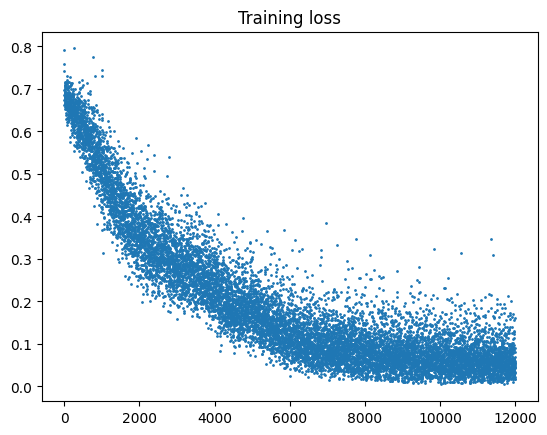

In [17]:
# Move the validation data to GPU
val_features = val_features.to(device)
val_labels = val_labels.to(device)

max_epochs = 150
print('Start training')
train_losses = []
val_losses = []

for epoch in tqdm(range(max_epochs)):
    running_loss = 0.0
    for i, data in enumerate(train_loader):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        our_net.train()
        outputs = our_net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if i % 20 == 19:    # print every 20 mini-batches
            # print(f'[{epoch + 1}, {i + 1:5d}] training loss: {running_loss / 20:.3f}')
            train_losses.append(running_loss / 20)
            running_loss = 0.0
        
print('Finished Training')

# Create a figure and subplots
plt.scatter(range(len(train_losses)), train_losses, s=1)
plt.title('Training loss')

### Testing the model

In [18]:
# load test data
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    num_workers=0,
    worker_init_fn=seed_worker,
    batch_size=best_params["batch_size"],
    shuffle=False,
)

our_net.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        output = our_net(x)
        probs = torch.sigmoid(output)
        all_preds.append(probs.cpu())
        all_targets.append(y)

# Concatenate predictions into a single tensor
all_preds = torch.cat(all_preds, dim=0)
all_targets = torch.cat(all_targets, dim=0)

In [19]:
### for the test set
our_net.eval()
probs = []

with torch.no_grad():
    
    for x, y in test_loader:
        x = x.to(device)
        logits = our_net(x)
        prob = torch.sigmoid(logits)  # this gives real-valued probability between 0 and 1
        probs.append(prob.cpu())

probs = torch.cat(probs).numpy()  # Final numpy array of predictions


In [20]:
all_logits = []
all_labels = []

our_net.eval()
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        logits = our_net(x).squeeze()
        all_logits.append(logits.cpu())
        all_labels.append(y.cpu())

# Convert one-hot labels to single binary class
labels_true = torch.cat(all_labels, dim=0)
labels_true = torch.argmax(labels_true, dim=1).numpy()

# Convert logits to probabilities
pred_logits = torch.cat(all_logits, dim=0)[:,1]
pred_probs = torch.sigmoid(pred_logits).numpy()


In [21]:
auroc = roc_auc_score(labels_true, pred_probs)
print(f"AUROC: {auroc:.4f}")

AUROC: 0.6494


## 2. `eGFP-CUX1`

In [98]:
xf = 'eGFP-CUX1'
train_features = util.make_ohe_features_tensor(data_folder + training_files_dict[xf]['train-fasta'])
train_labels = util.make_ohe_labels_tensor(data_folder + training_files_dict[xf]['train-label'])
# Convert them into torch dataset
train_dataset = TutorialDataSet(train_features, train_labels)

val_features = util.make_ohe_features_tensor(data_folder + training_files_dict[xf]['val-fasta'])
val_labels = util.make_ohe_labels_tensor(data_folder + training_files_dict[xf]['val-label'])
# Convert them into torch dataset
val_dataset = TutorialDataSet(val_features, val_labels)

test_features = util.make_ohe_features_tensor(data_folder + training_files_dict[xf]['test-fasta'])
test_labels = util.make_ohe_labels_tensor(data_folder + training_files_dict[xf]['test-label'])
# Convert them into torch dataset
test_dataset = TutorialDataSet(test_features, test_labels)

# Instantiate our model
our_net = TutorialNet()
# Move our model to the GPU
our_net = our_net.to(device)


### Tweak Tuning hyperparameters

In [100]:
def objective(trial):
    # Define hyperparameter search space
    batch_size = trial.suggest_categorical("batch_size", [1, 2, 4, 8])
    kernel_size = trial.suggest_categorical("kernel_size", [6, 12, 18, 24])
    num_filters = trial.suggest_categorical("num_filters", [16, 64, 128, 256, 512])
    optimizer_name = trial.suggest_categorical("optimizer", ["adam", "sgd"])
    # lr = trial.suggest_float("lr", 1e-6, 1e-2, log=True)
    lr = trial.suggest_categorical("lr", [1e-6, 1e-5, 1e-4, 1e-3, 1e-2])

    train_loader = torch.utils.data.DataLoader(
        train_dataset,
        num_workers=0,
        worker_init_fn=seed_worker,
        batch_size=batch_size,
        shuffle=True,
    )

    val_loader = torch.utils.data.DataLoader(
        val_dataset,
        num_workers=0,
        worker_init_fn=seed_worker,
        batch_size=batch_size,
        shuffle=True,
    )

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = TutorialNet(kernel_size=kernel_size, num_filters=num_filters).to(device)

    if optimizer_name == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    criterion = CEL

    for epoch in range(1):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()

            logits = model(x)  
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

    # Validation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            if y.ndimension() > 1:  # Check if y is one-hot encoded
                y = y.argmax(dim=1)
            logits = model(x)
            preds = logits.argmax(dim=1) 
            correct += (preds == y).sum().item()
            total += y.size(0)

    acc = correct / total
    return acc

# Run the study
study = optuna.create_study(direction="maximize")
study.optimize(objective, timeout=1200)

# Best trial
print("Best trial:")
trial = study.best_trial
print(f"  Accuracy: {trial.value}")
print("  Params:")
for key, value in trial.params.items():
    print(f"    {key}: {value}")


[I 2025-04-11 22:16:22,579] A new study created in memory with name: no-name-de28a14e-abfd-42e0-b4ea-7fc220ae2896
[I 2025-04-11 22:16:27,570] Trial 0 finished with value: 0.49955317247542447 and parameters: {'batch_size': 2, 'kernel_size': 12, 'num_filters': 512, 'optimizer': 'sgd', 'lr': 0.01}. Best is trial 0 with value: 0.49955317247542447.
[I 2025-04-11 22:16:31,940] Trial 1 finished with value: 0.5058087578194816 and parameters: {'batch_size': 2, 'kernel_size': 6, 'num_filters': 512, 'optimizer': 'adam', 'lr': 1e-06}. Best is trial 1 with value: 0.5058087578194816.
[I 2025-04-11 22:16:39,253] Trial 2 finished with value: 0.49776586237712245 and parameters: {'batch_size': 1, 'kernel_size': 18, 'num_filters': 512, 'optimizer': 'sgd', 'lr': 1e-05}. Best is trial 1 with value: 0.5058087578194816.
[I 2025-04-11 22:16:47,144] Trial 3 finished with value: 0.4906166219839142 and parameters: {'batch_size': 1, 'kernel_size': 6, 'num_filters': 128, 'optimizer': 'adam', 'lr': 1e-06}. Best is 

Best trial:
  Accuracy: 0.5478105451295799
  Params:
    batch_size: 4
    kernel_size: 6
    num_filters: 64
    optimizer: adam
    lr: 1e-05


### Running the training with the tuned hyperparameters

In [101]:
best_params = study.best_trial.params

our_net = TutorialNet(
    kernel_size=best_params["kernel_size"],
    num_filters=best_params["num_filters"]
).to(device)

if best_params["optimizer"] == "adam":
    optimizer = torch.optim.Adam(our_net.parameters(), lr=best_params["lr"])
else:
    optimizer = torch.optim.SGD(our_net.parameters(), lr=best_params["lr"], momentum=0.9)

full_train_dataset = torch.utils.data.ConcatDataset([train_dataset, val_dataset])

train_loader = torch.utils.data.DataLoader(
    full_train_dataset,
    num_workers=0,
    worker_init_fn=seed_worker,
    batch_size=best_params['batch_size'],
    shuffle=True,
)

criterion = CEL

Start training


100%|██████████| 300/300 [14:13<00:00,  2.84s/it]

Finished Training


Text(0.5, 1.0, 'Training loss')

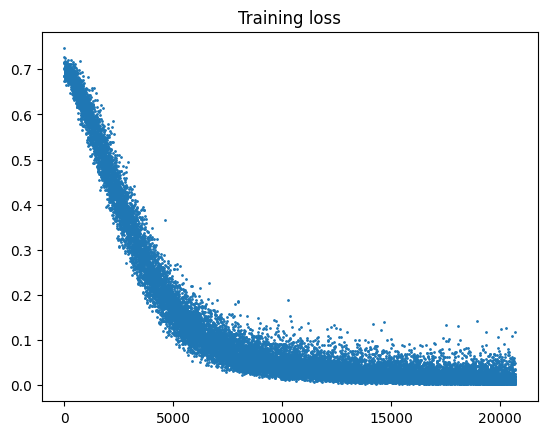

In [102]:
# Move the validation data to GPU
val_features = val_features.to(device)
val_labels = val_labels.to(device)

max_epochs = 300
print('Start training')
train_losses = []
val_losses = []

for epoch in tqdm(range(max_epochs)):
    running_loss = 0.0
    for i, data in enumerate(train_loader):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        our_net.train()
        outputs = our_net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if i % 20 == 19:    # print every 20 mini-batches
            # print(f'[{epoch + 1}, {i + 1:5d}] training loss: {running_loss / 20:.3f}')
            train_losses.append(running_loss / 20)
            running_loss = 0.0
        
print('Finished Training')

# Create a figure and subplots
plt.scatter(range(len(train_losses)), train_losses, s=1)
plt.title('Training loss')

### Testing the model

In [103]:
# load test data
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    num_workers=0,
    worker_init_fn=seed_worker,
    batch_size=best_params["batch_size"],
    shuffle=False,
)

our_net.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        output = our_net(x)
        probs = torch.sigmoid(output)
        all_preds.append(probs.cpu())
        all_targets.append(y)

# Concatenate predictions into a single tensor
all_preds = torch.cat(all_preds, dim=0)
all_targets = torch.cat(all_targets, dim=0)

In [104]:
### for the test set
our_net.eval()
probs = []

with torch.no_grad():
    
    for x, y in test_loader:
        x = x.to(device)
        logits = our_net(x)
        prob = torch.sigmoid(logits)  # this gives real-valued probability between 0 and 1
        probs.append(prob.cpu())

probs = torch.cat(probs).numpy()  # Final numpy array of predictions


In [105]:
all_logits = []
all_labels = []

our_net.eval()
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        logits = our_net(x).squeeze()
        all_logits.append(logits.cpu())
        all_labels.append(y.cpu())

# Convert one-hot labels to single binary class
labels_true = torch.cat(all_labels, dim=0)
labels_true = torch.argmax(labels_true, dim=1).numpy()

# Convert logits to probabilities
pred_logits = torch.cat(all_logits, dim=0)[:,1]
pred_probs = torch.sigmoid(pred_logits).numpy()


In [106]:
auroc = roc_auc_score(labels_true, pred_probs)
print(f"AUROC: {auroc:.4f}")

AUROC: 0.5893


## 3. `eGFP-ELK1`

In [30]:
xf = 'eGFP-ELK1'
train_features = util.make_ohe_features_tensor(data_folder + training_files_dict[xf]['train-fasta'])
train_labels = util.make_ohe_labels_tensor(data_folder + training_files_dict[xf]['train-label'])
# Convert them into torch dataset
train_dataset = TutorialDataSet(train_features, train_labels)

val_features = util.make_ohe_features_tensor(data_folder + training_files_dict[xf]['val-fasta'])
val_labels = util.make_ohe_labels_tensor(data_folder + training_files_dict[xf]['val-label'])
# Convert them into torch dataset
val_dataset = TutorialDataSet(val_features, val_labels)

test_features = util.make_ohe_features_tensor(data_folder + training_files_dict[xf]['test-fasta'])
test_labels = util.make_ohe_labels_tensor(data_folder + training_files_dict[xf]['test-label'])
# Convert them into torch dataset
test_dataset = TutorialDataSet(test_features, test_labels)

# Instantiate our model
our_net = TutorialNet()
# Move our model to the GPU
our_net = our_net.to(device)

### Tweak Tuning parameters

In [31]:
def objective(trial):
    # Define hyperparameter search space
    batch_size = trial.suggest_categorical("batch_size", [1, 2, 4, 8])
    kernel_size = trial.suggest_categorical("kernel_size", [6, 12, 18, 24])
    num_filters = trial.suggest_categorical("num_filters", [16, 64, 128, 256, 512])
    optimizer_name = trial.suggest_categorical("optimizer", ["adam", "sgd"])
    # lr = trial.suggest_float("lr", 1e-6, 1e-2, log=True)
    lr = trial.suggest_categorical("lr", [1e-6, 1e-5, 1e-4, 1e-3, 1e-2])

    train_loader = torch.utils.data.DataLoader(
        train_dataset,
        num_workers=0,
        worker_init_fn=seed_worker,
        batch_size=batch_size,
        shuffle=True,
    )

    val_loader = torch.utils.data.DataLoader(
        val_dataset,
        num_workers=0,
        worker_init_fn=seed_worker,
        batch_size=batch_size,
        shuffle=True,
    )

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = TutorialNet(kernel_size=kernel_size, num_filters=num_filters).to(device)

    if optimizer_name == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    criterion = CEL

    for epoch in range(1):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()

            logits = model(x)  
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

    # Validation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            if y.ndimension() > 1:  # Check if y is one-hot encoded
                y = y.argmax(dim=1)
            logits = model(x)
            preds = logits.argmax(dim=1) 
            correct += (preds == y).sum().item()
            total += y.size(0)

    acc = correct / total
    return acc

# Run the study
study = optuna.create_study(direction="maximize")
study.optimize(objective, timeout=900)

# Best trial
print("Best trial:")
trial = study.best_trial
print(f"  Accuracy: {trial.value}")
print("  Params:")
for key, value in trial.params.items():
    print(f"    {key}: {value}")


[I 2025-04-11 15:22:45,050] A new study created in memory with name: no-name-7642453a-1afa-48d7-96e6-fe697675ac54
[I 2025-04-11 15:22:47,645] Trial 0 finished with value: 0.5 and parameters: {'batch_size': 4, 'kernel_size': 6, 'num_filters': 128, 'optimizer': 'adam', 'lr': 0.001}. Best is trial 0 with value: 0.5.
[I 2025-04-11 15:22:49,986] Trial 1 finished with value: 0.586864406779661 and parameters: {'batch_size': 4, 'kernel_size': 18, 'num_filters': 64, 'optimizer': 'sgd', 'lr': 0.0001}. Best is trial 1 with value: 0.586864406779661.
[I 2025-04-11 15:22:52,281] Trial 2 finished with value: 0.5 and parameters: {'batch_size': 4, 'kernel_size': 6, 'num_filters': 16, 'optimizer': 'sgd', 'lr': 0.001}. Best is trial 1 with value: 0.586864406779661.
[I 2025-04-11 15:23:02,174] Trial 3 finished with value: 0.5 and parameters: {'batch_size': 1, 'kernel_size': 18, 'num_filters': 128, 'optimizer': 'adam', 'lr': 0.0001}. Best is trial 1 with value: 0.586864406779661.
[I 2025-04-11 15:23:04,535

Best trial:
  Accuracy: 0.6257062146892656
  Params:
    batch_size: 8
    kernel_size: 6
    num_filters: 256
    optimizer: adam
    lr: 0.001


### Running the training with the tuned hyperparameters

In [32]:
best_params = study.best_trial.params

our_net = TutorialNet(
    kernel_size=best_params["kernel_size"],
    num_filters=best_params["num_filters"]
).to(device)

if best_params["optimizer"] == "adam":
    optimizer = torch.optim.Adam(our_net.parameters(), lr=best_params["lr"])
else:
    optimizer = torch.optim.SGD(our_net.parameters(), lr=best_params["lr"], momentum=0.9)

full_train_dataset = torch.utils.data.ConcatDataset([train_dataset, val_dataset])

train_loader = torch.utils.data.DataLoader(
    full_train_dataset,
    num_workers=0,
    worker_init_fn=seed_worker,
    batch_size=best_params['batch_size'],
    shuffle=True,
)

criterion = CEL

Start training


100%|██████████| 120/120 [03:39<00:00,  1.83s/it]

Finished Training


Text(0.5, 1.0, 'Training loss')

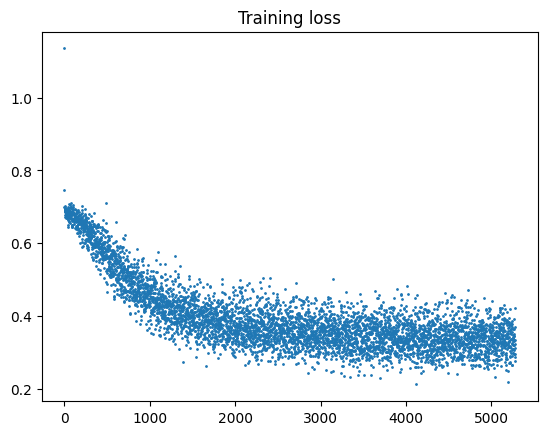

In [33]:
# Move the validation data to GPU
val_features = val_features.to(device)
val_labels = val_labels.to(device)

max_epochs = 120
print('Start training')
train_losses = []
val_losses = []

for epoch in tqdm(range(max_epochs)):
    running_loss = 0.0
    for i, data in enumerate(train_loader):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        our_net.train()
        outputs = our_net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if i % 20 == 19:    # print every 20 mini-batches
            # print(f'[{epoch + 1}, {i + 1:5d}] training loss: {running_loss / 20:.3f}')
            train_losses.append(running_loss / 20)
            running_loss = 0.0
        
print('Finished Training')

# Create a figure and subplots
plt.scatter(range(len(train_losses)), train_losses, s=1)
plt.title('Training loss')

### Testing the model

In [34]:
# load test data
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    num_workers=0,
    worker_init_fn=seed_worker,
    batch_size=best_params["batch_size"],
    shuffle=False,
)

our_net.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        output = our_net(x)
        probs = torch.sigmoid(output)
        all_preds.append(probs.cpu())
        all_targets.append(y)

# Concatenate predictions into a single tensor
all_preds = torch.cat(all_preds, dim=0)
all_targets = torch.cat(all_targets, dim=0)

In [35]:
### for the test set
our_net.eval()
probs = []

with torch.no_grad():
    
    for x, y in test_loader:
        x = x.to(device)
        logits = our_net(x)
        prob = torch.sigmoid(logits)  # this gives real-valued probability between 0 and 1
        probs.append(prob.cpu())

probs = torch.cat(probs).numpy()  # Final numpy array of predictions


In [36]:
all_logits = []
all_labels = []

our_net.eval()
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        logits = our_net(x).squeeze()
        all_logits.append(logits.cpu())
        all_labels.append(y.cpu())

# Convert one-hot labels to single binary class
labels_true = torch.cat(all_labels, dim=0)
labels_true = torch.argmax(labels_true, dim=1).numpy()

# Convert logits to probabilities
pred_logits = torch.cat(all_logits, dim=0)[:,1]
pred_probs = torch.sigmoid(pred_logits).numpy()


In [37]:
auroc = roc_auc_score(labels_true, pred_probs)
print(f"AUROC: {auroc:.4f}") # AUROC: 0.7997
#'batch_size': 8,
#'kernel_size': 6,
#'num_filters': 256,
#'optimizer': 'sgd',
#'lr': 0.0016163273042389726

AUROC: 0.7590


## 4. `eGFP-ETV1`

In [113]:
xf = 'eGFP-ETV1'
train_features = util.make_ohe_features_tensor(data_folder + training_files_dict[xf]['train-fasta'])
train_labels = util.make_ohe_labels_tensor(data_folder + training_files_dict[xf]['train-label'])
# Convert them into torch dataset
train_dataset = TutorialDataSet(train_features, train_labels)

val_features = util.make_ohe_features_tensor(data_folder + training_files_dict[xf]['val-fasta'])
val_labels = util.make_ohe_labels_tensor(data_folder + training_files_dict[xf]['val-label'])
# Convert them into torch dataset
val_dataset = TutorialDataSet(val_features, val_labels)

test_features = util.make_ohe_features_tensor(data_folder + training_files_dict[xf]['test-fasta'])
test_labels = util.make_ohe_labels_tensor(data_folder + training_files_dict[xf]['test-label'])
# Convert them into torch dataset
test_dataset = TutorialDataSet(test_features, test_labels)

# Instantiate our model
our_net = TutorialNet()
# Move our model to the GPU
our_net = our_net.to(device)


### Tweak Tuning Parameters

In [114]:
def objective(trial):
    # Define hyperparameter search space
    batch_size = trial.suggest_categorical("batch_size", [1, 2, 4, 8])
    kernel_size = trial.suggest_categorical("kernel_size", [6, 12, 18, 24])
    num_filters = trial.suggest_categorical("num_filters", [16, 64, 128, 256, 512])
    optimizer_name = trial.suggest_categorical("optimizer", ["adam", "sgd"])
    #lr = trial.suggest_float("lr", 1e-6, 1e-2, log=True)
    lr = trial.suggest_categorical("lr", [1e-6, 1e-5, 1e-4, 1e-3, 1e-2])

    train_loader = torch.utils.data.DataLoader(
        train_dataset,
        num_workers=0,
        worker_init_fn=seed_worker,
        batch_size=batch_size,
        shuffle=True,
    )

    val_loader = torch.utils.data.DataLoader(
        val_dataset,
        num_workers=0,
        worker_init_fn=seed_worker,
        batch_size=batch_size,
        shuffle=True,
    )

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = TutorialNet(kernel_size=kernel_size, num_filters=num_filters).to(device)

    if optimizer_name == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    criterion = CEL

    for epoch in range(1):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()

            logits = model(x)  
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

    # Validation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            if y.ndimension() > 1:  # Check if y is one-hot encoded
                y = y.argmax(dim=1)
            logits = model(x)
            preds = logits.argmax(dim=1) 
            correct += (preds == y).sum().item()
            total += y.size(0)

    acc = correct / total
    return acc

# Run the study
study = optuna.create_study(direction="maximize")
study.optimize(objective, timeout=900)

# Best trial
print("Best trial:")
trial = study.best_trial
print(f"  Accuracy: {trial.value}")
print("  Params:")
for key, value in trial.params.items():
    print(f"    {key}: {value}")


[I 2025-04-11 23:00:00,219] A new study created in memory with name: no-name-8ee4c4c7-3189-4b54-bb36-bce15127f5b2
[I 2025-04-11 23:00:14,098] Trial 0 finished with value: 0.5 and parameters: {'batch_size': 1, 'kernel_size': 24, 'num_filters': 256, 'optimizer': 'sgd', 'lr': 0.0001}. Best is trial 0 with value: 0.5.
[I 2025-04-11 23:00:18,071] Trial 1 finished with value: 0.5989911727616646 and parameters: {'batch_size': 4, 'kernel_size': 18, 'num_filters': 128, 'optimizer': 'adam', 'lr': 0.0001}. Best is trial 1 with value: 0.5989911727616646.
[I 2025-04-11 23:00:21,822] Trial 2 finished with value: 0.544766708701135 and parameters: {'batch_size': 4, 'kernel_size': 12, 'num_filters': 512, 'optimizer': 'adam', 'lr': 1e-06}. Best is trial 1 with value: 0.5989911727616646.
[I 2025-04-11 23:00:33,971] Trial 3 finished with value: 0.478562421185372 and parameters: {'batch_size': 1, 'kernel_size': 12, 'num_filters': 512, 'optimizer': 'sgd', 'lr': 1e-06}. Best is trial 1 with value: 0.59899117

Best trial:
  Accuracy: 0.6639344262295082
  Params:
    batch_size: 8
    kernel_size: 18
    num_filters: 512
    optimizer: adam
    lr: 0.001


### Running the training with the tuned hyperparameters

In [107]:
best_params = study.best_trial.params

our_net = TutorialNet(
    kernel_size=best_params["kernel_size"],
    num_filters=best_params["num_filters"]
).to(device)

if best_params["optimizer"] == "adam":
    optimizer = torch.optim.Adam(our_net.parameters(), lr=best_params["lr"])
else:
    optimizer = torch.optim.SGD(our_net.parameters(), lr=best_params["lr"], momentum=0.9)

full_train_dataset = torch.utils.data.ConcatDataset([train_dataset, val_dataset])

train_loader = torch.utils.data.DataLoader(
    full_train_dataset,
    num_workers=0,
    worker_init_fn=seed_worker,
    batch_size=best_params['batch_size'],
    shuffle=True,
)

criterion = CEL

Start training


100%|██████████| 200/200 [09:21<00:00,  2.81s/it]

Finished Training


Text(0.5, 1.0, 'Training loss')

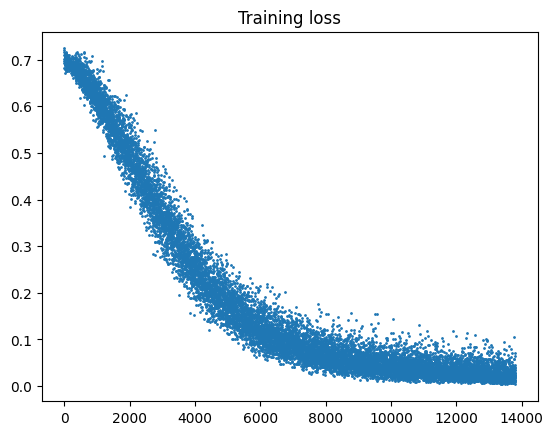

In [108]:
# Move the validation data to GPU
val_features = val_features.to(device)
val_labels = val_labels.to(device)

max_epochs = 200
print('Start training')
train_losses = []
val_losses = []

for epoch in tqdm(range(max_epochs)):
    running_loss = 0.0
    for i, data in enumerate(train_loader):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        our_net.train()
        outputs = our_net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if i % 20 == 19:    # print every 20 mini-batches
            # print(f'[{epoch + 1}, {i + 1:5d}] training loss: {running_loss / 20:.3f}')
            train_losses.append(running_loss / 20)
            running_loss = 0.0
        
print('Finished Training')

# Create a figure and subplots
plt.scatter(range(len(train_losses)), train_losses, s=1)
plt.title('Training loss')

### Testing the model

In [109]:
# load test data
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    num_workers=0,
    worker_init_fn=seed_worker,
    batch_size=best_params["batch_size"],
    shuffle=False,
)

our_net.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        output = our_net(x)
        probs = torch.sigmoid(output)
        all_preds.append(probs.cpu())
        all_targets.append(y)

# Concatenate predictions into a single tensor
all_preds = torch.cat(all_preds, dim=0)
all_targets = torch.cat(all_targets, dim=0)

In [110]:
### for the test set
our_net.eval()
probs = []

with torch.no_grad():
    
    for x, y in test_loader:
        x = x.to(device)
        logits = our_net(x)
        prob = torch.sigmoid(logits)  # this gives real-valued probability between 0 and 1
        probs.append(prob.cpu())

probs = torch.cat(probs).numpy()  # Final numpy array of predictions


In [111]:
all_logits = []
all_labels = []

our_net.eval()
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        logits = our_net(x).squeeze()
        all_logits.append(logits.cpu())
        all_labels.append(y.cpu())

# Convert one-hot labels to single binary class
labels_true = torch.cat(all_labels, dim=0)
labels_true = torch.argmax(labels_true, dim=1).numpy()

# Convert logits to probabilities
pred_logits = torch.cat(all_logits, dim=0)[:,1]
pred_probs = torch.sigmoid(pred_logits).numpy()


In [112]:
auroc = roc_auc_score(labels_true, pred_probs)
print(f"AUROC: {auroc:.4f}")
# AUROC: 0.8653
#'batch_size': 4,
#'kernel_size': 6,
#'num_filters': 256,
#'optimizer': 'adam',
#'lr': 0.0001

AUROC: 0.5841


## 5. `eGFP-FOXJ2`

In [125]:
xf = 'eGFP-FOXJ2'
train_features = util.make_ohe_features_tensor(data_folder + training_files_dict[xf]['train-fasta'])
train_labels = util.make_ohe_labels_tensor(data_folder + training_files_dict[xf]['train-label'])
# Convert them into torch dataset
train_dataset = TutorialDataSet(train_features, train_labels)

val_features = util.make_ohe_features_tensor(data_folder + training_files_dict[xf]['val-fasta'])
val_labels = util.make_ohe_labels_tensor(data_folder + training_files_dict[xf]['val-label'])
# Convert them into torch dataset
val_dataset = TutorialDataSet(val_features, val_labels)

test_features = util.make_ohe_features_tensor(data_folder + training_files_dict[xf]['test-fasta'])
test_labels = util.make_ohe_labels_tensor(data_folder + training_files_dict[xf]['test-label'])
# Convert them into torch dataset
test_dataset = TutorialDataSet(test_features, test_labels)

# Instantiate our model
our_net = TutorialNet()
# Move our model to the GPU
our_net = our_net.to(device)

### Tweak Tuning Parameters

In [126]:
def objective(trial):
    # Define hyperparameter search space
    batch_size = trial.suggest_categorical("batch_size", [1, 2, 4, 8])
    kernel_size = trial.suggest_categorical("kernel_size", [6, 12, 18, 24])
    num_filters = trial.suggest_categorical("num_filters", [16, 64, 128, 256, 512])
    optimizer_name = trial.suggest_categorical("optimizer", ["adam", "sgd"])
    #lr = trial.suggest_float("lr", 1e-6, 1e-2, log=True)
    lr = trial.suggest_categorical("lr", [1e-6, 1e-5, 1e-4, 1e-3, 1e-2])

    train_loader = torch.utils.data.DataLoader(
        train_dataset,
        num_workers=0,
        worker_init_fn=seed_worker,
        batch_size=batch_size,
        shuffle=True,
    )

    val_loader = torch.utils.data.DataLoader(
        val_dataset,
        num_workers=0,
        worker_init_fn=seed_worker,
        batch_size=batch_size,
        shuffle=True,
    )

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = TutorialNet(kernel_size=kernel_size, num_filters=num_filters).to(device)

    if optimizer_name == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    criterion = CEL

    for epoch in range(1):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()

            logits = model(x)  
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

    # Validation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            if y.ndimension() > 1:  # Check if y is one-hot encoded
                y = y.argmax(dim=1)
            logits = model(x)
            preds = logits.argmax(dim=1) 
            correct += (preds == y).sum().item()
            total += y.size(0)

    acc = correct / total
    return acc

# Run the study
study = optuna.create_study(direction="maximize")
study.optimize(objective, timeout=1200)

# Best trial
print("Best trial:")
trial = study.best_trial
print(f"  Accuracy: {trial.value}")
print("  Params:")
for key, value in trial.params.items():
    print(f"    {key}: {value}")


[I 2025-04-11 23:44:22,533] A new study created in memory with name: no-name-31a39803-60b3-46a3-bcd1-a75bcbd4e303
[I 2025-04-11 23:44:28,839] Trial 0 finished with value: 0.49712230215827335 and parameters: {'batch_size': 2, 'kernel_size': 18, 'num_filters': 64, 'optimizer': 'sgd', 'lr': 1e-06}. Best is trial 0 with value: 0.49712230215827335.
[I 2025-04-11 23:44:33,949] Trial 1 finished with value: 0.4985611510791367 and parameters: {'batch_size': 2, 'kernel_size': 12, 'num_filters': 128, 'optimizer': 'adam', 'lr': 0.0001}. Best is trial 1 with value: 0.4985611510791367.
[I 2025-04-11 23:44:43,162] Trial 2 finished with value: 0.5 and parameters: {'batch_size': 1, 'kernel_size': 18, 'num_filters': 256, 'optimizer': 'sgd', 'lr': 0.001}. Best is trial 2 with value: 0.5.
[I 2025-04-11 23:44:48,141] Trial 3 finished with value: 0.5028776978417266 and parameters: {'batch_size': 2, 'kernel_size': 24, 'num_filters': 64, 'optimizer': 'adam', 'lr': 1e-06}. Best is trial 3 with value: 0.5028776

Best trial:
  Accuracy: 0.5877697841726619
  Params:
    batch_size: 8
    kernel_size: 24
    num_filters: 512
    optimizer: adam
    lr: 0.0001


### Running the training with the tuned hyperparameters

In [127]:
best_params = study.best_trial.params

our_net = TutorialNet(
    kernel_size=best_params["kernel_size"],
    num_filters=best_params["num_filters"]
).to(device)

if best_params["optimizer"] == "adam":
    optimizer = torch.optim.Adam(our_net.parameters(), lr=best_params["lr"])
else:
    optimizer = torch.optim.SGD(our_net.parameters(), lr=best_params["lr"], momentum=0.9)

full_train_dataset = torch.utils.data.ConcatDataset([train_dataset, val_dataset])

train_loader = torch.utils.data.DataLoader(
    full_train_dataset,
    num_workers=0,
    worker_init_fn=seed_worker,
    batch_size=best_params['batch_size'],
    shuffle=True,
)

criterion = CEL

Start training


100%|██████████| 120/120 [04:47<00:00,  2.40s/it]

Finished Training


Text(0.5, 1.0, 'Training loss')

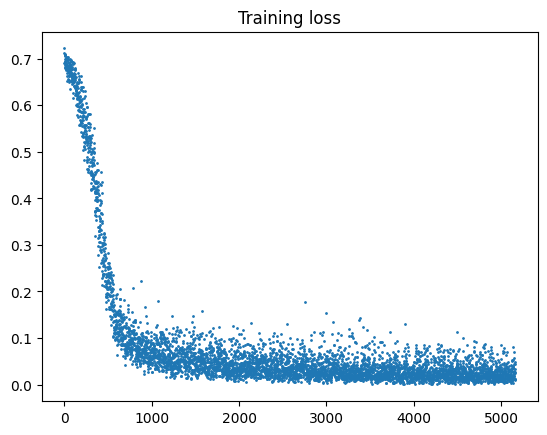

In [128]:
# Move the validation data to GPU
val_features = val_features.to(device)
val_labels = val_labels.to(device)

max_epochs = 120
print('Start training')
train_losses = []
val_losses = []

for epoch in tqdm(range(max_epochs)):
    running_loss = 0.0
    for i, data in enumerate(train_loader):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        our_net.train()
        outputs = our_net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if i % 20 == 19:    # print every 20 mini-batches
            # print(f'[{epoch + 1}, {i + 1:5d}] training loss: {running_loss / 20:.3f}')
            train_losses.append(running_loss / 20)
            running_loss = 0.0
        
print('Finished Training')

# Create a figure and subplots
plt.scatter(range(len(train_losses)), train_losses, s=1)
plt.title('Training loss')

### Testing the model

In [129]:
# load test data
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    num_workers=0,
    worker_init_fn=seed_worker,
    batch_size=best_params["batch_size"],
    shuffle=False,
)

our_net.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        output = our_net(x)
        probs = torch.sigmoid(output)
        all_preds.append(probs.cpu())
        all_targets.append(y)

# Concatenate predictions into a single tensor
all_preds = torch.cat(all_preds, dim=0)
all_targets = torch.cat(all_targets, dim=0)

In [130]:
### for the test set
our_net.eval()
probs = []

with torch.no_grad():
    
    for x, y in test_loader:
        x = x.to(device)
        logits = our_net(x)
        prob = torch.sigmoid(logits)  # this gives real-valued probability between 0 and 1
        probs.append(prob.cpu())

probs = torch.cat(probs).numpy()  # Final numpy array of predictions


In [131]:
all_logits = []
all_labels = []

our_net.eval()
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        logits = our_net(x).squeeze()
        all_logits.append(logits.cpu())
        all_labels.append(y.cpu())

# Convert one-hot labels to single binary class
labels_true = torch.cat(all_labels, dim=0)
labels_true = torch.argmax(labels_true, dim=1).numpy()

# Convert logits to probabilities
pred_logits = torch.cat(all_logits, dim=0)[:,1]
pred_probs = torch.sigmoid(pred_logits).numpy()


In [132]:
auroc = roc_auc_score(labels_true, pred_probs)
print(f"AUROC: {auroc:.4f}")

# AUROC: 0.6936
#{'batch_size': 4,
#'kernel_size': 6,
#'num_filters': 64,
#'optimizer': 'sgd',
#'lr': 0.001}

AUROC: 0.6384


## 6. `eGFP-KLF13`

In [54]:
xf = 'eGFP-KLF13'
train_features = util.make_ohe_features_tensor(data_folder + training_files_dict[xf]['train-fasta'])
train_labels = util.make_ohe_labels_tensor(data_folder + training_files_dict[xf]['train-label'])
# Convert them into torch dataset
train_dataset = TutorialDataSet(train_features, train_labels)

val_features = util.make_ohe_features_tensor(data_folder + training_files_dict[xf]['val-fasta'])
val_labels = util.make_ohe_labels_tensor(data_folder + training_files_dict[xf]['val-label'])
# Convert them into torch dataset
val_dataset = TutorialDataSet(val_features, val_labels)

test_features = util.make_ohe_features_tensor(data_folder + training_files_dict[xf]['test-fasta'])
test_labels = util.make_ohe_labels_tensor(data_folder + training_files_dict[xf]['test-label'])
# Convert them into torch dataset
test_dataset = TutorialDataSet(test_features, test_labels)

# Instantiate our model
our_net = TutorialNet()
# Move our model to the GPU
our_net = our_net.to(device)

### Tweak Tuning Parameters

In [55]:
def objective(trial):
    # Define hyperparameter search space
    batch_size = trial.suggest_categorical("batch_size", [1, 2, 4, 8])
    kernel_size = trial.suggest_categorical("kernel_size", [6, 12, 18, 24])
    num_filters = trial.suggest_categorical("num_filters", [16, 64, 128, 256, 512])
    optimizer_name = trial.suggest_categorical("optimizer", ["adam", "sgd"])
    # lr = trial.suggest_float("lr", 1e-6, 1e-2, log=True)
    lr = trial.suggest_categorical("lr", [1e-6, 1e-5, 1e-4, 1e-3, 1e-2])

    train_loader = torch.utils.data.DataLoader(
        train_dataset,
        num_workers=0,
        worker_init_fn=seed_worker,
        batch_size=batch_size,
        shuffle=True,
    )

    val_loader = torch.utils.data.DataLoader(
        val_dataset,
        num_workers=0,
        worker_init_fn=seed_worker,
        batch_size=batch_size,
        shuffle=True,
    )

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = TutorialNet(kernel_size=kernel_size, num_filters=num_filters).to(device)

    if optimizer_name == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    criterion = CEL

    for epoch in range(1):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()

            logits = model(x)  
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

    # Validation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            if y.ndimension() > 1:  # Check if y is one-hot encoded
                y = y.argmax(dim=1)
            logits = model(x)
            preds = logits.argmax(dim=1) 
            correct += (preds == y).sum().item()
            total += y.size(0)

    acc = correct / total
    return acc

# Run the study
study = optuna.create_study(direction="maximize")
study.optimize(objective, timeout=1200)

# Best trial
print("Best trial:")
trial = study.best_trial
print(f"  Accuracy: {trial.value}")
print("  Params:")
for key, value in trial.params.items():
    print(f"    {key}: {value}")


[I 2025-04-11 16:24:28,200] A new study created in memory with name: no-name-8e55ddfd-a281-4c21-9d99-ec14cedff001
[I 2025-04-11 16:24:30,020] Trial 0 finished with value: 0.5682878081279147 and parameters: {'batch_size': 8, 'kernel_size': 24, 'num_filters': 256, 'optimizer': 'adam', 'lr': 0.00031991609604767947}. Best is trial 0 with value: 0.5682878081279147.
[I 2025-04-11 16:24:35,348] Trial 1 finished with value: 0.5403064623584277 and parameters: {'batch_size': 2, 'kernel_size': 12, 'num_filters': 64, 'optimizer': 'sgd', 'lr': 7.016041641642806e-06}. Best is trial 0 with value: 0.5682878081279147.
[I 2025-04-11 16:24:45,607] Trial 2 finished with value: 0.5176548967355097 and parameters: {'batch_size': 1, 'kernel_size': 12, 'num_filters': 512, 'optimizer': 'sgd', 'lr': 1.7992342877211805e-05}. Best is trial 0 with value: 0.5682878081279147.
[I 2025-04-11 16:24:51,080] Trial 3 finished with value: 0.5469686875416389 and parameters: {'batch_size': 2, 'kernel_size': 12, 'num_filters':

Best trial:
  Accuracy: 0.6302465023317788
  Params:
    batch_size: 8
    kernel_size: 24
    num_filters: 256
    optimizer: adam
    lr: 0.00022646752607594786


### Running the training with the tuned hyperparameters

In [56]:
best_params = study.best_trial.params

our_net = TutorialNet(
    kernel_size=best_params["kernel_size"],
    num_filters=best_params["num_filters"]
).to(device)

if best_params["optimizer"] == "adam":
    optimizer = torch.optim.Adam(our_net.parameters(), lr=best_params["lr"])
else:
    optimizer = torch.optim.SGD(our_net.parameters(), lr=best_params["lr"], momentum=0.9)

full_train_dataset = torch.utils.data.ConcatDataset([train_dataset, val_dataset])

train_loader = torch.utils.data.DataLoader(
    full_train_dataset,
    num_workers=0,
    worker_init_fn=seed_worker,
    batch_size=best_params['batch_size'],
    shuffle=True,
)

criterion = CEL

Start training


100%|██████████| 120/120 [03:45<00:00,  1.88s/it]

Finished Training


Text(0.5, 1.0, 'Training loss')

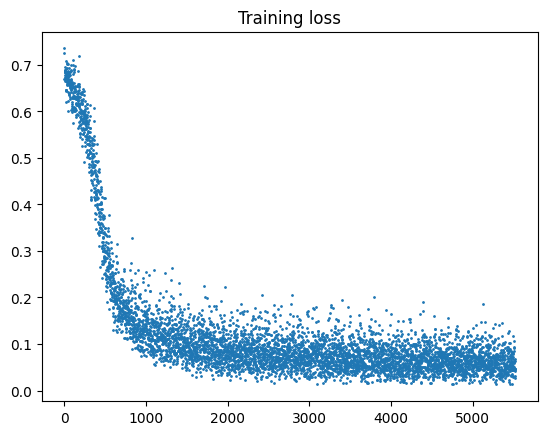

In [57]:
# Move the validation data to GPU
val_features = val_features.to(device)
val_labels = val_labels.to(device)

max_epochs = 120
print('Start training')
train_losses = []
val_losses = []

for epoch in tqdm(range(max_epochs)):
    running_loss = 0.0
    for i, data in enumerate(train_loader):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        our_net.train()
        outputs = our_net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if i % 20 == 19:    # print every 20 mini-batches
            # print(f'[{epoch + 1}, {i + 1:5d}] training loss: {running_loss / 20:.3f}')
            train_losses.append(running_loss / 20)
            running_loss = 0.0
        
print('Finished Training')

# Create a figure and subplots
plt.scatter(range(len(train_losses)), train_losses, s=1)
plt.title('Training loss')

### Testing the model

In [58]:
# load test data
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    num_workers=0,
    worker_init_fn=seed_worker,
    batch_size=best_params["batch_size"],
    shuffle=False,
)

our_net.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        output = our_net(x)
        probs = torch.sigmoid(output)
        all_preds.append(probs.cpu())
        all_targets.append(y)

# Concatenate predictions into a single tensor
all_preds = torch.cat(all_preds, dim=0)
all_targets = torch.cat(all_targets, dim=0)

In [59]:
### for the test set
our_net.eval()
probs = []

with torch.no_grad():
    
    for x, y in test_loader:
        x = x.to(device)
        logits = our_net(x)
        prob = torch.sigmoid(logits)  # this gives real-valued probability between 0 and 1
        probs.append(prob.cpu())

probs = torch.cat(probs).numpy()  # Final numpy array of predictions


In [60]:
all_logits = []
all_labels = []

our_net.eval()
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        logits = our_net(x).squeeze()
        all_logits.append(logits.cpu())
        all_labels.append(y.cpu())

# Convert one-hot labels to single binary class
labels_true = torch.cat(all_labels, dim=0)
labels_true = torch.argmax(labels_true, dim=1).numpy()

# Convert logits to probabilities
pred_logits = torch.cat(all_logits, dim=0)[:,1]
pred_probs = torch.sigmoid(pred_logits).numpy()


In [61]:
auroc = roc_auc_score(labels_true, pred_probs)
print(f"AUROC: {auroc:.4f}")
#AUROC: 0.6250
#batch_size= 8
#kernel_size= 18
#num_filters= 64
#optimizer= sgd
#lr= 0.0001

AUROC: 0.6027


## 7. `eGFP-NR2C2`

In [115]:
xf = 'eGFP-NR2C2'
train_features = util.make_ohe_features_tensor(data_folder + training_files_dict[xf]['train-fasta'])
train_labels = util.make_ohe_labels_tensor(data_folder + training_files_dict[xf]['train-label'])
# Convert them into torch dataset
train_dataset = TutorialDataSet(train_features, train_labels)

val_features = util.make_ohe_features_tensor(data_folder + training_files_dict[xf]['val-fasta'])
val_labels = util.make_ohe_labels_tensor(data_folder + training_files_dict[xf]['val-label'])
# Convert them into torch dataset
val_dataset = TutorialDataSet(val_features, val_labels)

test_features = util.make_ohe_features_tensor(data_folder + training_files_dict[xf]['test-fasta'])
test_labels = util.make_ohe_labels_tensor(data_folder + training_files_dict[xf]['test-label'])
# Convert them into torch dataset
test_dataset = TutorialDataSet(test_features, test_labels)

# Instantiate our model
our_net = TutorialNet()
# Move our model to the GPU
our_net = our_net.to(device)


### Tweak Tuning parameters 

In [116]:
def objective(trial):
    # Define hyperparameter search space
    batch_size = trial.suggest_categorical("batch_size", [1, 2, 4, 8])
    kernel_size = trial.suggest_categorical("kernel_size", [6, 12, 18, 24])
    num_filters = trial.suggest_categorical("num_filters", [16, 64, 128, 256, 512])
    optimizer_name = trial.suggest_categorical("optimizer", ["adam", "sgd"])
    # lr = trial.suggest_float("lr", 1e-6, 1e-2, log=True)
    lr = trial.suggest_categorical("lr", [1e-6, 1e-5, 1e-4, 1e-3, 1e-2])

    train_loader = torch.utils.data.DataLoader(
        train_dataset,
        num_workers=0,
        worker_init_fn=seed_worker,
        batch_size=batch_size,
        shuffle=True,
    )

    val_loader = torch.utils.data.DataLoader(
        val_dataset,
        num_workers=0,
        worker_init_fn=seed_worker,
        batch_size=batch_size,
        shuffle=True,
    )

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = TutorialNet(kernel_size=kernel_size, num_filters=num_filters).to(device)

    if optimizer_name == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    criterion = CEL

    for epoch in range(1):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()

            logits = model(x)  
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

    # Validation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            if y.ndimension() > 1:  # Check if y is one-hot encoded
                y = y.argmax(dim=1)
            logits = model(x)
            preds = logits.argmax(dim=1) 
            correct += (preds == y).sum().item()
            total += y.size(0)

    acc = correct / total
    return acc

# Run the study
study = optuna.create_study(direction="maximize")
study.optimize(objective, timeout=1500)

# Best trial
print("Best trial:")
trial = study.best_trial
print(f"  Accuracy: {trial.value}")
print("  Params:")
for key, value in trial.params.items():
    print(f"    {key}: {value}")


[I 2025-04-11 23:15:10,831] A new study created in memory with name: no-name-43c7c888-ab7d-4104-843f-e9ec9737ef27
[I 2025-04-11 23:15:12,108] Trial 0 finished with value: 0.5659875996457041 and parameters: {'batch_size': 8, 'kernel_size': 18, 'num_filters': 64, 'optimizer': 'adam', 'lr': 1e-05}. Best is trial 0 with value: 0.5659875996457041.
[I 2025-04-11 23:15:21,255] Trial 1 finished with value: 0.520814880425155 and parameters: {'batch_size': 1, 'kernel_size': 24, 'num_filters': 256, 'optimizer': 'sgd', 'lr': 1e-05}. Best is trial 0 with value: 0.5659875996457041.
[I 2025-04-11 23:15:31,187] Trial 2 finished with value: 0.5004428697962799 and parameters: {'batch_size': 1, 'kernel_size': 24, 'num_filters': 16, 'optimizer': 'adam', 'lr': 0.01}. Best is trial 0 with value: 0.5659875996457041.
[I 2025-04-11 23:15:35,641] Trial 3 finished with value: 0.49867139061116034 and parameters: {'batch_size': 2, 'kernel_size': 18, 'num_filters': 512, 'optimizer': 'adam', 'lr': 0.01}. Best is tri

KeyboardInterrupt: 

In [118]:
best_params['num_filters'] = 256
best_params['lr'] = 0.0001

### Running the training with the tuned hyperparameters

In [119]:
best_params = study.best_trial.params

our_net = TutorialNet(
    kernel_size=best_params["kernel_size"],
    num_filters=best_params["num_filters"]
).to(device)

if best_params["optimizer"] == "adam":
    optimizer = torch.optim.Adam(our_net.parameters(), lr=best_params["lr"])
else:
    optimizer = torch.optim.SGD(our_net.parameters(), lr=best_params["lr"], momentum=0.9)

full_train_dataset = torch.utils.data.ConcatDataset([train_dataset, val_dataset])

train_loader = torch.utils.data.DataLoader(
    full_train_dataset,
    num_workers=0,
    worker_init_fn=seed_worker,
    batch_size=best_params['batch_size'],
    shuffle=True,
)

criterion = CEL

Start training


100%|██████████| 200/200 [10:44<00:00,  3.22s/it]

Finished Training


Text(0.5, 1.0, 'Training loss')

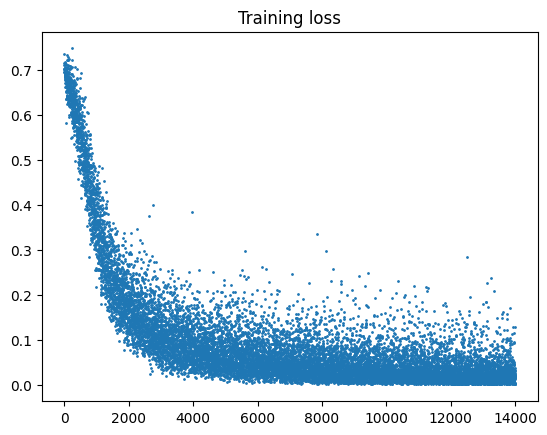

In [120]:
# Move the validation data to GPU
val_features = val_features.to(device)
val_labels = val_labels.to(device)

max_epochs = 200
print('Start training')
train_losses = []
val_losses = []

for epoch in tqdm(range(max_epochs)):
    running_loss = 0.0
    for i, data in enumerate(train_loader):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        our_net.train()
        outputs = our_net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if i % 20 == 19:    # print every 20 mini-batches
            # print(f'[{epoch + 1}, {i + 1:5d}] training loss: {running_loss / 20:.3f}')
            train_losses.append(running_loss / 20)
            running_loss = 0.0
        
print('Finished Training')

# Create a figure and subplots
plt.scatter(range(len(train_losses)), train_losses, s=1)
plt.title('Training loss')

### Testing the model

In [121]:
# load test data
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    num_workers=0,
    worker_init_fn=seed_worker,
    batch_size=best_params["batch_size"],
    shuffle=False,
)

our_net.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        output = our_net(x)
        probs = torch.sigmoid(output)
        all_preds.append(probs.cpu())
        all_targets.append(y)

# Concatenate predictions into a single tensor
all_preds = torch.cat(all_preds, dim=0)
all_targets = torch.cat(all_targets, dim=0)

In [122]:
### for the test set
our_net.eval()
probs = []

with torch.no_grad():
    
    for x, y in test_loader:
        x = x.to(device)
        logits = our_net(x)
        prob = torch.sigmoid(logits)  # this gives real-valued probability between 0 and 1
        probs.append(prob.cpu())

probs = torch.cat(probs).numpy()  # Final numpy array of predictions


In [123]:
all_logits = []
all_labels = []

our_net.eval()
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        logits = our_net(x).squeeze()
        all_logits.append(logits.cpu())
        all_labels.append(y.cpu())

# Convert one-hot labels to single binary class
labels_true = torch.cat(all_labels, dim=0)
labels_true = torch.argmax(labels_true, dim=1).numpy()

# Convert logits to probabilities
pred_logits = torch.cat(all_logits, dim=0)[:,1]
pred_probs = torch.sigmoid(pred_logits).numpy()


In [124]:
auroc = roc_auc_score(labels_true, pred_probs)
print(f"AUROC: {auroc:.4f}")

AUROC: 0.6377


## 8. `MAX`

In [70]:
xf = 'MAX'
train_features = util.make_ohe_features_tensor(data_folder + training_files_dict[xf]['train-fasta'])
train_labels = util.make_ohe_labels_tensor(data_folder + training_files_dict[xf]['train-label'])
# Convert them into torch dataset
train_dataset = TutorialDataSet(train_features, train_labels)

val_features = util.make_ohe_features_tensor(data_folder + training_files_dict[xf]['val-fasta'])
val_labels = util.make_ohe_labels_tensor(data_folder + training_files_dict[xf]['val-label'])
# Convert them into torch dataset
val_dataset = TutorialDataSet(val_features, val_labels)

test_features = util.make_ohe_features_tensor(data_folder + training_files_dict[xf]['test-fasta'])
test_labels = util.make_ohe_labels_tensor(data_folder + training_files_dict[xf]['test-label'])
# Convert them into torch dataset
test_dataset = TutorialDataSet(test_features, test_labels)

# Instantiate our model
our_net = TutorialNet()
# Move our model to the GPU
our_net = our_net.to(device)


### Tuning parameters

In [71]:
def objective(trial):
    # Define hyperparameter search space
    batch_size = trial.suggest_categorical("batch_size", [1, 2, 4, 8])
    kernel_size = trial.suggest_categorical("kernel_size", [6, 12, 18, 24])
    num_filters = trial.suggest_categorical("num_filters", [16, 64, 128, 256, 512])
    optimizer_name = trial.suggest_categorical("optimizer", ["adam", "sgd"])
    lr = trial.suggest_float("lr", 1e-6, 1e-2, log=True)
    # lr = trial.suggest_categorical("lr", [1e-6, 1e-5, 1e-4, 1e-3, 1e-2])

    train_loader = torch.utils.data.DataLoader(
        train_dataset,
        num_workers=0,
        worker_init_fn=seed_worker,
        batch_size=batch_size,
        shuffle=True,
    )

    val_loader = torch.utils.data.DataLoader(
        val_dataset,
        num_workers=0,
        worker_init_fn=seed_worker,
        batch_size=batch_size,
        shuffle=True,
    )

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = TutorialNet(kernel_size=kernel_size, num_filters=num_filters).to(device)

    if optimizer_name == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    criterion = CEL

    for epoch in range(1):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()

            logits = model(x)  
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

    # Validation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            if y.ndimension() > 1:  # Check if y is one-hot encoded
                y = y.argmax(dim=1)
            logits = model(x)
            preds = logits.argmax(dim=1) 
            correct += (preds == y).sum().item()
            total += y.size(0)

    acc = correct / total
    return acc

# Run the study
study = optuna.create_study(direction="maximize")
study.optimize(objective, timeout=1500)

# Best trial
print("Best trial:")
trial = study.best_trial
print(f"  Accuracy: {trial.value}")
print("  Params:")
for key, value in trial.params.items():
    print(f"    {key}: {value}")


[I 2025-04-11 17:16:10,475] A new study created in memory with name: no-name-1c032bcb-45a5-4860-9397-fc4dd65800ef
[I 2025-04-11 17:16:18,112] Trial 0 finished with value: 0.6339622641509434 and parameters: {'batch_size': 2, 'kernel_size': 6, 'num_filters': 512, 'optimizer': 'adam', 'lr': 1.3735077810025707e-05}. Best is trial 0 with value: 0.6339622641509434.
[I 2025-04-11 17:16:19,863] Trial 1 finished with value: 0.569811320754717 and parameters: {'batch_size': 8, 'kernel_size': 6, 'num_filters': 512, 'optimizer': 'sgd', 'lr': 0.004098908609460193}. Best is trial 0 with value: 0.6339622641509434.
[I 2025-04-11 17:16:34,341] Trial 2 finished with value: 0.5 and parameters: {'batch_size': 1, 'kernel_size': 6, 'num_filters': 128, 'optimizer': 'adam', 'lr': 0.00011966724700737933}. Best is trial 0 with value: 0.6339622641509434.
[I 2025-04-11 17:16:35,748] Trial 3 finished with value: 0.6283018867924528 and parameters: {'batch_size': 8, 'kernel_size': 18, 'num_filters': 256, 'optimizer':

Best trial:
  Accuracy: 0.7981132075471699
  Params:
    batch_size: 8
    kernel_size: 6
    num_filters: 256
    optimizer: adam
    lr: 0.0006669748620819501


### Running the training with the tuned hyperparameters

In [72]:
best_params = study.best_trial.params

our_net = TutorialNet(
    kernel_size=best_params["kernel_size"],
    num_filters=best_params["num_filters"]
).to(device)

if best_params["optimizer"] == "adam":
    optimizer = torch.optim.Adam(our_net.parameters(), lr=best_params["lr"])
else:
    optimizer = torch.optim.SGD(our_net.parameters(), lr=best_params["lr"], momentum=0.9)

full_train_dataset = torch.utils.data.ConcatDataset([train_dataset, val_dataset])

train_loader = torch.utils.data.DataLoader(
    full_train_dataset,
    num_workers=0,
    worker_init_fn=seed_worker,
    batch_size=best_params['batch_size'],
    shuffle=True,
)

criterion = CEL

Start training


100%|██████████| 120/120 [03:57<00:00,  1.98s/it]

Finished Training


Text(0.5, 1.0, 'Training loss')

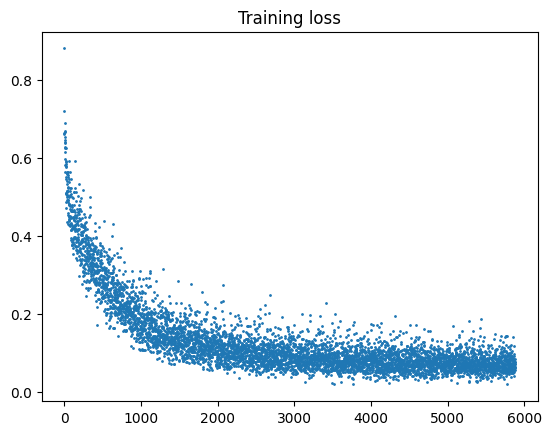

In [73]:
# Move the validation data to GPU
val_features = val_features.to(device)
val_labels = val_labels.to(device)

max_epochs = 120
print('Start training')
train_losses = []
val_losses = []

for epoch in tqdm(range(max_epochs)):
    running_loss = 0.0
    for i, data in enumerate(train_loader):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        our_net.train()
        outputs = our_net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if i % 20 == 19:    # print every 20 mini-batches
            # print(f'[{epoch + 1}, {i + 1:5d}] training loss: {running_loss / 20:.3f}')
            train_losses.append(running_loss / 20)
            running_loss = 0.0
        
print('Finished Training')

# Create a figure and subplots
plt.scatter(range(len(train_losses)), train_losses, s=1)
plt.title('Training loss')

### Testing the model

In [74]:
# load test data
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    num_workers=0,
    worker_init_fn=seed_worker,
    batch_size=best_params["batch_size"],
    shuffle=False,
)

our_net.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        output = our_net(x)
        probs = torch.sigmoid(output)
        all_preds.append(probs.cpu())
        all_targets.append(y)

# Concatenate predictions into a single tensor
all_preds = torch.cat(all_preds, dim=0)
all_targets = torch.cat(all_targets, dim=0)

In [75]:
### for the test set
our_net.eval()
probs = []

with torch.no_grad():
    
    for x, y in test_loader:
        x = x.to(device)
        logits = our_net(x)
        prob = torch.sigmoid(logits)  # this gives real-valued probability between 0 and 1
        probs.append(prob.cpu())

probs = torch.cat(probs).numpy()  # Final numpy array of predictions


In [76]:
all_logits = []
all_labels = []

our_net.eval()
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        logits = our_net(x).squeeze()
        all_logits.append(logits.cpu())
        all_labels.append(y.cpu())

# Convert one-hot labels to single binary class
labels_true = torch.cat(all_labels, dim=0)
labels_true = torch.argmax(labels_true, dim=1).numpy()

# Convert logits to probabilities
pred_logits = torch.cat(all_logits, dim=0)[:,1]
pred_probs = torch.sigmoid(pred_logits).numpy()


In [77]:
auroc = roc_auc_score(labels_true, pred_probs)
print(f"AUROC: {auroc:.4f}")

AUROC: 0.9330


## 9. `NR2F1`

In [78]:
xf = 'NR2F1'
train_features = util.make_ohe_features_tensor(data_folder + training_files_dict[xf]['train-fasta'])
train_labels = util.make_ohe_labels_tensor(data_folder + training_files_dict[xf]['train-label'])
# Convert them into torch dataset
train_dataset = TutorialDataSet(train_features, train_labels)

val_features = util.make_ohe_features_tensor(data_folder + training_files_dict[xf]['val-fasta'])
val_labels = util.make_ohe_labels_tensor(data_folder + training_files_dict[xf]['val-label'])
# Convert them into torch dataset
val_dataset = TutorialDataSet(val_features, val_labels)

test_features = util.make_ohe_features_tensor(data_folder + training_files_dict[xf]['test-fasta'])
test_labels = util.make_ohe_labels_tensor(data_folder + training_files_dict[xf]['test-label'])
# Convert them into torch dataset
test_dataset = TutorialDataSet(test_features, test_labels)

# Instantiate our model
our_net = TutorialNet()
# Move our model to the GPU
our_net = our_net.to(device)

### Tuning parameters

In [79]:
def objective(trial):
    # Define hyperparameter search space
    batch_size = trial.suggest_categorical("batch_size", [1, 2, 4, 8])
    kernel_size = trial.suggest_categorical("kernel_size", [6, 12, 18, 24])
    num_filters = trial.suggest_categorical("num_filters", [16, 64, 128, 256, 512])
    optimizer_name = trial.suggest_categorical("optimizer", ["adam", "sgd"])
    lr = trial.suggest_float("lr", 1e-6, 1e-2, log=True)
    # lr = trial.suggest_categorical("lr", [1e-6, 1e-5, 1e-4, 1e-3, 1e-2])

    train_loader = torch.utils.data.DataLoader(
        train_dataset,
        num_workers=0,
        worker_init_fn=seed_worker,
        batch_size=batch_size,
        shuffle=True,
    )

    val_loader = torch.utils.data.DataLoader(
        val_dataset,
        num_workers=0,
        worker_init_fn=seed_worker,
        batch_size=batch_size,
        shuffle=True,
    )

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = TutorialNet(kernel_size=kernel_size, num_filters=num_filters).to(device)

    if optimizer_name == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    criterion = CEL

    for epoch in range(1):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()

            logits = model(x)  
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

    # Validation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            if y.ndimension() > 1:  # Check if y is one-hot encoded
                y = y.argmax(dim=1)
            logits = model(x)
            preds = logits.argmax(dim=1) 
            correct += (preds == y).sum().item()
            total += y.size(0)

    acc = correct / total
    return acc

# Run the study
study = optuna.create_study(direction="maximize")
study.optimize(objective, timeout=900)

# Best trial
print("Best trial:")
trial = study.best_trial
print(f"  Accuracy: {trial.value}")
print("  Params:")
for key, value in trial.params.items():
    print(f"    {key}: {value}")


[I 2025-04-11 17:45:09,930] A new study created in memory with name: no-name-7bd129f8-7c0e-499c-8c6d-9551866b22a9
[I 2025-04-11 17:45:11,353] Trial 0 finished with value: 0.6160365058670143 and parameters: {'batch_size': 8, 'kernel_size': 18, 'num_filters': 512, 'optimizer': 'adam', 'lr': 0.000886452042669009}. Best is trial 0 with value: 0.6160365058670143.
[I 2025-04-11 17:45:14,392] Trial 1 finished with value: 0.5228161668839635 and parameters: {'batch_size': 4, 'kernel_size': 6, 'num_filters': 256, 'optimizer': 'adam', 'lr': 4.877009444789983e-06}. Best is trial 0 with value: 0.6160365058670143.
[I 2025-04-11 17:45:17,252] Trial 2 finished with value: 0.5 and parameters: {'batch_size': 4, 'kernel_size': 18, 'num_filters': 256, 'optimizer': 'adam', 'lr': 0.0029134280373979767}. Best is trial 0 with value: 0.6160365058670143.
[I 2025-04-11 17:45:22,754] Trial 3 finished with value: 0.5 and parameters: {'batch_size': 2, 'kernel_size': 12, 'num_filters': 16, 'optimizer': 'adam', 'lr':

Best trial:
  Accuracy: 0.6577574967405476
  Params:
    batch_size: 8
    kernel_size: 6
    num_filters: 512
    optimizer: adam
    lr: 0.0002048658309910133


### Running the training with the tuned hyperparameters

In [81]:
best_params = study.best_trial.params

our_net = TutorialNet(
    kernel_size=best_params["kernel_size"],
    num_filters=best_params["num_filters"]
).to(device)

if best_params["optimizer"] == "adam":
    optimizer = torch.optim.Adam(our_net.parameters(), lr=best_params["lr"])
else:
    optimizer = torch.optim.SGD(our_net.parameters(), lr=best_params["lr"], momentum=0.9)

full_train_dataset = torch.utils.data.ConcatDataset([train_dataset, val_dataset])

train_loader = torch.utils.data.DataLoader(
    full_train_dataset,
    num_workers=0,
    worker_init_fn=seed_worker,
    batch_size=best_params['batch_size'],
    shuffle=True,
)

criterion = CEL

Start training


100%|██████████| 120/120 [04:04<00:00,  2.04s/it]

Finished Training


Text(0.5, 1.0, 'Training loss')

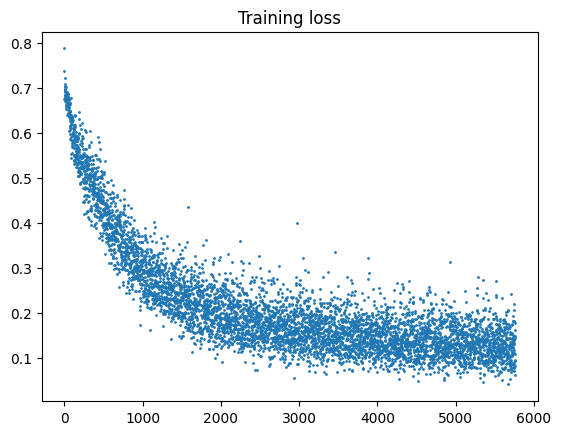

In [82]:
# Move the validation data to GPU
val_features = val_features.to(device)
val_labels = val_labels.to(device)

max_epochs = 120
print('Start training')
train_losses = []
val_losses = []

for epoch in tqdm(range(max_epochs)):
    running_loss = 0.0
    for i, data in enumerate(train_loader):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        our_net.train()
        outputs = our_net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if i % 20 == 19:    # print every 20 mini-batches
            # print(f'[{epoch + 1}, {i + 1:5d}] training loss: {running_loss / 20:.3f}')
            train_losses.append(running_loss / 20)
            running_loss = 0.0
        
print('Finished Training')

# Create a figure and subplots
plt.scatter(range(len(train_losses)), train_losses, s=1)
plt.title('Training loss')

### Testing the model

In [83]:
# load test data
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    num_workers=0,
    worker_init_fn=seed_worker,
    batch_size=best_params["batch_size"],
    shuffle=False,
)

our_net.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        output = our_net(x)
        probs = torch.sigmoid(output)
        all_preds.append(probs.cpu())
        all_targets.append(y)

# Concatenate predictions into a single tensor
all_preds = torch.cat(all_preds, dim=0)
all_targets = torch.cat(all_targets, dim=0)

In [84]:
### for the test set
our_net.eval()
probs = []

with torch.no_grad():
    
    for x, y in test_loader:
        x = x.to(device)
        logits = our_net(x)
        prob = torch.sigmoid(logits)  # this gives real-valued probability between 0 and 1
        probs.append(prob.cpu())

probs = torch.cat(probs).numpy()  # Final numpy array of predictions


In [85]:
all_logits = []
all_labels = []

our_net.eval()
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        logits = our_net(x).squeeze()
        all_logits.append(logits.cpu())
        all_labels.append(y.cpu())

# Convert one-hot labels to single binary class
labels_true = torch.cat(all_labels, dim=0)
labels_true = torch.argmax(labels_true, dim=1).numpy()

# Convert logits to probabilities
pred_logits = torch.cat(all_logits, dim=0)[:,1]
pred_probs = torch.sigmoid(pred_logits).numpy()


In [86]:
auroc = roc_auc_score(labels_true, pred_probs)
print(f"AUROC: {auroc:.4f}")

AUROC: 0.8263


## 10. `PKNOX1`

In [87]:
xf = 'PKNOX1'
train_features = util.make_ohe_features_tensor(data_folder + training_files_dict[xf]['train-fasta'])
train_labels = util.make_ohe_labels_tensor(data_folder + training_files_dict[xf]['train-label'])
# Convert them into torch dataset
train_dataset = TutorialDataSet(train_features, train_labels)

val_features = util.make_ohe_features_tensor(data_folder + training_files_dict[xf]['val-fasta'])
val_labels = util.make_ohe_labels_tensor(data_folder + training_files_dict[xf]['val-label'])
# Convert them into torch dataset
val_dataset = TutorialDataSet(val_features, val_labels)

test_features = util.make_ohe_features_tensor(data_folder + training_files_dict[xf]['test-fasta'])
test_labels = util.make_ohe_labels_tensor(data_folder + training_files_dict[xf]['test-label'])
# Convert them into torch dataset
test_dataset = TutorialDataSet(test_features, test_labels)

# Instantiate our model
our_net = TutorialNet()
# Move our model to the GPU
our_net = our_net.to(device)

### Tuning Hyperparameters

In [88]:
def objective(trial):
    # Define hyperparameter search space
    batch_size = trial.suggest_categorical("batch_size", [1, 2, 4, 8])
    kernel_size = trial.suggest_categorical("kernel_size", [6, 12, 18, 24])
    num_filters = trial.suggest_categorical("num_filters", [16, 64, 128, 256, 512])
    optimizer_name = trial.suggest_categorical("optimizer", ["adam", "sgd"])
    lr = trial.suggest_float("lr", 1e-6, 1e-2, log=True)
    # lr = trial.suggest_categorical("lr", [1e-6, 1e-5, 1e-4, 1e-3, 1e-2])

    train_loader = torch.utils.data.DataLoader(
        train_dataset,
        num_workers=0,
        worker_init_fn=seed_worker,
        batch_size=batch_size,
        shuffle=True,
    )

    val_loader = torch.utils.data.DataLoader(
        val_dataset,
        num_workers=0,
        worker_init_fn=seed_worker,
        batch_size=batch_size,
        shuffle=True,
    )

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = TutorialNet(kernel_size=kernel_size, num_filters=num_filters).to(device)

    if optimizer_name == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    criterion = CEL

    for epoch in range(1):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()

            logits = model(x)  
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

    # Validation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            if y.ndimension() > 1:  # Check if y is one-hot encoded
                y = y.argmax(dim=1)
            logits = model(x)
            preds = logits.argmax(dim=1) 
            correct += (preds == y).sum().item()
            total += y.size(0)

    acc = correct / total
    return acc

# Run the study
study = optuna.create_study(direction="maximize")
study.optimize(objective, timeout=900)

# Best trial
print("Best trial:")
trial = study.best_trial
print(f"  Accuracy: {trial.value}")
print("  Params:")
for key, value in trial.params.items():
    print(f"    {key}: {value}")


[I 2025-04-11 18:04:18,114] A new study created in memory with name: no-name-eb53015f-87e4-47cc-82c2-9c18edbb5e33
[I 2025-04-11 18:04:19,746] Trial 0 finished with value: 0.639386189258312 and parameters: {'batch_size': 8, 'kernel_size': 12, 'num_filters': 512, 'optimizer': 'sgd', 'lr': 0.001850144269434411}. Best is trial 0 with value: 0.639386189258312.
[I 2025-04-11 18:04:21,463] Trial 1 finished with value: 0.5485933503836317 and parameters: {'batch_size': 8, 'kernel_size': 18, 'num_filters': 16, 'optimizer': 'sgd', 'lr': 0.00029886664762657564}. Best is trial 0 with value: 0.639386189258312.
[I 2025-04-11 18:04:28,902] Trial 2 finished with value: 0.5 and parameters: {'batch_size': 2, 'kernel_size': 18, 'num_filters': 256, 'optimizer': 'adam', 'lr': 0.0008854010177022461}. Best is trial 0 with value: 0.639386189258312.
[I 2025-04-11 18:04:35,241] Trial 3 finished with value: 0.5300511508951407 and parameters: {'batch_size': 2, 'kernel_size': 18, 'num_filters': 128, 'optimizer': 's

Best trial:
  Accuracy: 0.7979539641943734
  Params:
    batch_size: 8
    kernel_size: 6
    num_filters: 512
    optimizer: adam
    lr: 0.00023212766503346476


### Running the training with the tuned hyperparameters

In [89]:
best_params = study.best_trial.params

our_net = TutorialNet(
    kernel_size=best_params["kernel_size"],
    num_filters=best_params["num_filters"]
).to(device)

if best_params["optimizer"] == "adam":
    optimizer = torch.optim.Adam(our_net.parameters(), lr=best_params["lr"])
else:
    optimizer = torch.optim.SGD(our_net.parameters(), lr=best_params["lr"], momentum=0.9)

full_train_dataset = torch.utils.data.ConcatDataset([train_dataset, val_dataset])

train_loader = torch.utils.data.DataLoader(
    full_train_dataset,
    num_workers=0,
    worker_init_fn=seed_worker,
    batch_size=best_params['batch_size'],
    shuffle=True,
)

criterion = CEL

Start training


100%|██████████| 120/120 [04:06<00:00,  2.05s/it]

Finished Training


Text(0.5, 1.0, 'Training loss')

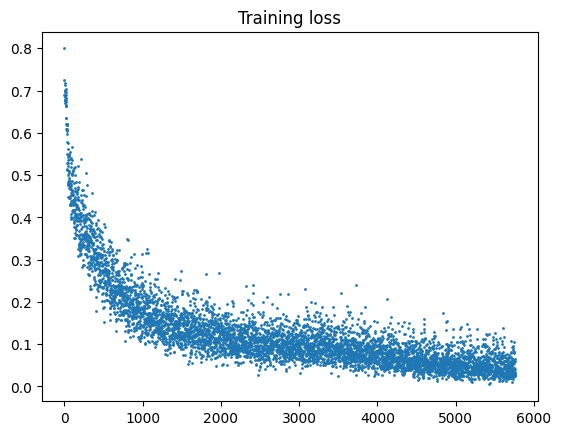

In [90]:
# Move the validation data to GPU
val_features = val_features.to(device)
val_labels = val_labels.to(device)

max_epochs = 120
print('Start training')
train_losses = []
val_losses = []

for epoch in tqdm(range(max_epochs)):
    running_loss = 0.0
    for i, data in enumerate(train_loader):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        our_net.train()
        outputs = our_net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if i % 20 == 19:    # print every 20 mini-batches
            # print(f'[{epoch + 1}, {i + 1:5d}] training loss: {running_loss / 20:.3f}')
            train_losses.append(running_loss / 20)
            running_loss = 0.0
        
print('Finished Training')

# Create a figure and subplots
plt.scatter(range(len(train_losses)), train_losses, s=1)
plt.title('Training loss')

### Testing the model

In [91]:
# load test data
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    num_workers=0,
    worker_init_fn=seed_worker,
    batch_size=best_params["batch_size"],
    shuffle=False,
)

our_net.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        output = our_net(x)
        probs = torch.sigmoid(output)
        all_preds.append(probs.cpu())
        all_targets.append(y)

# Concatenate predictions into a single tensor
all_preds = torch.cat(all_preds, dim=0)
all_targets = torch.cat(all_targets, dim=0)

In [92]:
### for the test set
our_net.eval()
probs = []

with torch.no_grad():
    
    for x, y in test_loader:
        x = x.to(device)
        logits = our_net(x)
        prob = torch.sigmoid(logits)  # this gives real-valued probability between 0 and 1
        probs.append(prob.cpu())

probs = torch.cat(probs).numpy()  # Final numpy array of predictions


In [93]:
all_logits = []
all_labels = []

our_net.eval()
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        logits = our_net(x).squeeze()
        all_logits.append(logits.cpu())
        all_labels.append(y.cpu())

# Convert one-hot labels to single binary class
labels_true = torch.cat(all_labels, dim=0)
labels_true = torch.argmax(labels_true, dim=1).numpy()

# Convert logits to probabilities
pred_logits = torch.cat(all_logits, dim=0)[:,1]
pred_probs = torch.sigmoid(pred_logits).numpy()


In [94]:
auroc = roc_auc_score(labels_true, pred_probs)
print(f"AUROC: {auroc:.4f}")
"""
AUROC: 0.9321
'batch_size': 4,
 'kernel_size': 6,
 'num_filters': 256,
 'optimizer': 'sgd',
 'lr': 0.001
"""

AUROC: 0.9197


"\nAUROC: 0.9321\n'batch_size': 4,\n 'kernel_size': 6,\n 'num_filters': 256,\n 'optimizer': 'sgd',\n 'lr': 0.001\n"

# Evalution files

In [133]:
evaluation_sets

['CTCF', 'CEBPB', 'NRF1', 'MGA']

In [134]:
# Dictionary to store the result
category_dict = defaultdict(dict)

for filename in os.listdir('data/encode-chip'):
    parts = filename.split('_')
    category = parts[0]
    if category in evaluation_sets:
        
        # Extract the "type" and "extension"
        type_ext = '.'.join(filename.split('.')[-2:])
        
        # e.g., 'train.fasta' → 'train-fasta'
        type_key = type_ext.replace('.', '-')

        category_dict[category][type_key] = filename

# Convert to regular dict if desired
evaluation_files_dict = dict(category_dict)

## 1. CTCF

In [ ]:
xf = 'CTCF'
train_features = util.make_ohe_features_tensor(data_folder + evaluation_files_dict[xf]['train-fasta'])
train_labels = util.make_ohe_labels_tensor(data_folder + evaluation_files_dict[xf]['train-label'])
# Convert them into torch dataset
train_dataset = TutorialDataSet(train_features, train_labels)

val_features = util.make_ohe_features_tensor(data_folder + evaluation_files_dict[xf]['val-fasta'])
val_labels = util.make_ohe_labels_tensor(data_folder + evaluation_files_dict[xf]['val-label'])
# Convert them into torch dataset
val_dataset = TutorialDataSet(val_features, val_labels)

test_features = util.make_ohe_features_tensor(data_folder + evaluation_files_dict[xf]['test-fasta'])

# Instantiate our model
our_net = TutorialNet()
# Move our model to the GPU
our_net = our_net.to(device)


### Tweak tuning parameters

In [ ]:
def objective(trial):
    # Define hyperparameter search space
    batch_size = trial.suggest_categorical("batch_size", [1, 2, 4, 8])
    kernel_size = trial.suggest_categorical("kernel_size", [6, 12, 18, 24])
    num_filters = trial.suggest_categorical("num_filters", [16, 64, 128, 256, 512])
    optimizer_name = trial.suggest_categorical("optimizer", ["adam", "sgd"])
    lr = trial.suggest_categorical("lr", [1e-6, 1e-5, 1e-4, 1e-3, 1e-2])

    train_loader = torch.utils.data.DataLoader(
        train_dataset,
        num_workers=0,
        worker_init_fn=seed_worker,
        batch_size=batch_size,
        shuffle=True,
    )

    val_loader = torch.utils.data.DataLoader(
        val_dataset,
        num_workers=0,
        worker_init_fn=seed_worker,
        batch_size=batch_size,
        shuffle=True,
    )

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = TutorialNet(kernel_size=kernel_size, num_filters=num_filters).to(device)

    if optimizer_name == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    criterion = CEL

    for epoch in range(1):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()

            logits = model(x)  
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

    # Validation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            if y.ndimension() > 1:  # Check if y is one-hot encoded
                y = y.argmax(dim=1)
            logits = model(x)
            preds = logits.argmax(dim=1) 
            correct += (preds == y).sum().item()
            total += y.size(0)

    acc = correct / total
    return acc

# Run the study
study = optuna.create_study(direction="maximize")
study.optimize(objective, timeout=900)

# Best trial
print("Best trial:")
trial = study.best_trial
print(f"  Accuracy: {trial.value}")
print("  Params:")
for key, value in trial.params.items():
    print(f"    {key}: {value}")


### Running the training with the tuned hyperparameters

In [ ]:
best_params = study.best_trial.params

our_net = TutorialNet(
    kernel_size=best_params["kernel_size"],
    num_filters=best_params["num_filters"]
).to(device)

if best_params["optimizer"] == "adam":
    optimizer = torch.optim.Adam(our_net.parameters(), lr=best_params["lr"])
else:
    optimizer = torch.optim.SGD(our_net.parameters(), lr=best_params["lr"], momentum=0.9)

full_train_dataset = torch.utils.data.ConcatDataset([train_dataset, val_dataset])

train_loader = torch.utils.data.DataLoader(
    full_train_dataset,
    num_workers=0,
    worker_init_fn=seed_worker,
    batch_size=best_params['batch_size'],
    shuffle=True,
)

criterion = CEL

In [ ]:
# Move the validation data to GPU
val_features = val_features.to(device)
val_labels = val_labels.to(device)

max_epochs = 120
print('Start training')
train_losses = []
val_losses = []

for epoch in tqdm(range(max_epochs)):
    running_loss = 0.0
    for i, data in enumerate(train_loader):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        our_net.train()
        outputs = our_net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if i % 20 == 19:    # print every 20 mini-batches
            # print(f'[{epoch + 1}, {i + 1:5d}] training loss: {running_loss / 20:.3f}')
            train_losses.append(running_loss / 20)
            running_loss = 0.0
        
print('Finished Training')

# Create a figure and subplots
plt.scatter(range(len(train_losses)), train_losses, s=1)
plt.title('Training loss')

### Testing the model

In [ ]:
# load test data
test_loader = torch.utils.data.DataLoader(
    test_features,
    num_workers=0,
    worker_init_fn=seed_worker,
    batch_size=best_params["batch_size"],
    shuffle=False,
)

our_net.eval()
all_preds = []


with torch.no_grad():
    for x in test_loader:
        x = x.to(device)
        output = our_net(x)
        probs = torch.sigmoid(output)
        all_preds.append(probs.cpu())

# Concatenate predictions into a single tensor
all_preds = torch.cat(all_preds, dim=0)
pred_labels = all_preds.numpy()[:,1]

In [ ]:
with open(f'{xf}.test.predicted_labels', 'w') as f:
    for item in pred_labels:
        f.write(f"{item}\n")


## 2. CEBPB

In [141]:
xf = 'CEBPB'
train_features = util.make_ohe_features_tensor(data_folder + evaluation_files_dict[xf]['train-fasta'])
train_labels = util.make_ohe_labels_tensor(data_folder + evaluation_files_dict[xf]['train-label'])
# Convert them into torch dataset
train_dataset = TutorialDataSet(train_features, train_labels)

val_features = util.make_ohe_features_tensor(data_folder + evaluation_files_dict[xf]['val-fasta'])
val_labels = util.make_ohe_labels_tensor(data_folder + evaluation_files_dict[xf]['val-label'])
# Convert them into torch dataset
val_dataset = TutorialDataSet(val_features, val_labels)

test_features = util.make_ohe_features_tensor(data_folder + evaluation_files_dict[xf]['test-fasta'])

# Instantiate our model
our_net = TutorialNet()
# Move our model to the GPU
our_net = our_net.to(device)


### Tweak hyperparameters

In [142]:
def objective(trial):
    # Define hyperparameter search space
    batch_size = trial.suggest_categorical("batch_size", [1, 2, 4, 8])
    kernel_size = trial.suggest_categorical("kernel_size", [6, 12, 18, 24])
    num_filters = trial.suggest_categorical("num_filters", [16, 64, 128, 256, 512])
    optimizer_name = trial.suggest_categorical("optimizer", ["adam", "sgd"])
    lr = trial.suggest_categorical("lr", [1e-6, 1e-5, 1e-4, 1e-3, 1e-2])

    train_loader = torch.utils.data.DataLoader(
        train_dataset,
        num_workers=0,
        worker_init_fn=seed_worker,
        batch_size=batch_size,
        shuffle=True,
    )

    val_loader = torch.utils.data.DataLoader(
        val_dataset,
        num_workers=0,
        worker_init_fn=seed_worker,
        batch_size=batch_size,
        shuffle=True,
    )

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = TutorialNet(kernel_size=kernel_size, num_filters=num_filters).to(device)

    if optimizer_name == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    criterion = CEL

    for epoch in range(1):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()

            logits = model(x)  
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

    # Validation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            if y.ndimension() > 1:  # Check if y is one-hot encoded
                y = y.argmax(dim=1)
            logits = model(x)
            preds = logits.argmax(dim=1) 
            correct += (preds == y).sum().item()
            total += y.size(0)

    acc = correct / total
    return acc

# Run the study
study = optuna.create_study(direction="maximize")
study.optimize(objective, timeout=900)

# Best trial
print("Best trial:")
trial = study.best_trial
print(f"  Accuracy: {trial.value}")
print("  Params:")
for key, value in trial.params.items():
    print(f"    {key}: {value}")


[I 2025-04-12 05:36:26,031] A new study created in memory with name: no-name-1be87442-fae3-4304-837d-34c3080cc9c6
[I 2025-04-12 05:36:29,555] Trial 0 finished with value: 0.5 and parameters: {'batch_size': 4, 'kernel_size': 24, 'num_filters': 256, 'optimizer': 'adam', 'lr': 0.01}. Best is trial 0 with value: 0.5.
[I 2025-04-12 05:36:32,672] Trial 1 finished with value: 0.5168269230769231 and parameters: {'batch_size': 4, 'kernel_size': 24, 'num_filters': 16, 'optimizer': 'adam', 'lr': 1e-06}. Best is trial 1 with value: 0.5168269230769231.
[I 2025-04-12 05:36:34,235] Trial 2 finished with value: 0.5174278846153846 and parameters: {'batch_size': 8, 'kernel_size': 12, 'num_filters': 16, 'optimizer': 'adam', 'lr': 1e-06}. Best is trial 2 with value: 0.5174278846153846.
[I 2025-04-12 05:36:37,314] Trial 3 finished with value: 0.5258413461538461 and parameters: {'batch_size': 4, 'kernel_size': 6, 'num_filters': 128, 'optimizer': 'adam', 'lr': 1e-05}. Best is trial 3 with value: 0.5258413461

Best trial:
  Accuracy: 0.7932692307692307
  Params:
    batch_size: 8
    kernel_size: 24
    num_filters: 512
    optimizer: adam
    lr: 0.001


### Running the training with the tuned hyperparameters

In [143]:
best_params = study.best_trial.params

our_net = TutorialNet(
    kernel_size=best_params["kernel_size"],
    num_filters=best_params["num_filters"]
).to(device)

if best_params["optimizer"] == "adam":
    optimizer = torch.optim.Adam(our_net.parameters(), lr=best_params["lr"])
else:
    optimizer = torch.optim.SGD(our_net.parameters(), lr=best_params["lr"], momentum=0.9)

full_train_dataset = torch.utils.data.ConcatDataset([train_dataset, val_dataset])

train_loader = torch.utils.data.DataLoader(
    full_train_dataset,
    num_workers=0,
    worker_init_fn=seed_worker,
    batch_size=best_params['batch_size'],
    shuffle=True,
)

criterion = CEL

Start training


100%|██████████| 120/120 [04:13<00:00,  2.11s/it]

Finished Training


Text(0.5, 1.0, 'Training loss')

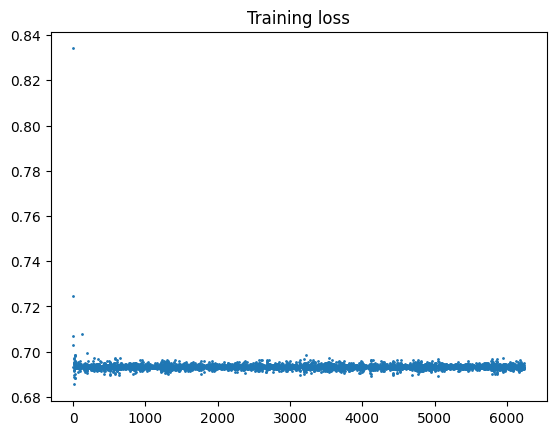

In [144]:
# Move the validation data to GPU
val_features = val_features.to(device)
val_labels = val_labels.to(device)

max_epochs = 120
print('Start training')
train_losses = []
val_losses = []

for epoch in tqdm(range(max_epochs)):
    running_loss = 0.0
    for i, data in enumerate(train_loader):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        our_net.train()
        outputs = our_net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if i % 20 == 19:    # print every 20 mini-batches
            # print(f'[{epoch + 1}, {i + 1:5d}] training loss: {running_loss / 20:.3f}')
            train_losses.append(running_loss / 20)
            running_loss = 0.0
        
print('Finished Training')

# Create a figure and subplots
plt.scatter(range(len(train_losses)), train_losses, s=1)
plt.title('Training loss')

### Testing the model

In [145]:
# load test data
test_loader = torch.utils.data.DataLoader(
    test_features,
    num_workers=0,
    worker_init_fn=seed_worker,
    batch_size=best_params["batch_size"],
    shuffle=False,
)

our_net.eval()
all_preds = []


with torch.no_grad():
    for x in test_loader:
        x = x.to(device)
        output = our_net(x)
        probs = torch.sigmoid(output)
        all_preds.append(probs.cpu())

# Concatenate predictions into a single tensor
all_preds = torch.cat(all_preds, dim=0)
pred_labels = all_preds.numpy()[:,1]

In [146]:
with open(f'{xf}.test.predicted_labels', 'w') as f:
    for item in pred_labels:
        f.write(f"{item}\n")


## 3. NRF1

In [147]:
xf = 'NRF1'
train_features = util.make_ohe_features_tensor(data_folder + evaluation_files_dict[xf]['train-fasta'])
train_labels = util.make_ohe_labels_tensor(data_folder + evaluation_files_dict[xf]['train-label'])
# Convert them into torch dataset
train_dataset = TutorialDataSet(train_features, train_labels)

val_features = util.make_ohe_features_tensor(data_folder + evaluation_files_dict[xf]['val-fasta'])
val_labels = util.make_ohe_labels_tensor(data_folder + evaluation_files_dict[xf]['val-label'])
# Convert them into torch dataset
val_dataset = TutorialDataSet(val_features, val_labels)

test_features = util.make_ohe_features_tensor(data_folder + evaluation_files_dict[xf]['test-fasta'])

# Instantiate our model
our_net = TutorialNet()
# Move our model to the GPU
our_net = our_net.to(device)


### Tweak tuning parameters

In [148]:
def objective(trial):
    # Define hyperparameter search space
    batch_size = trial.suggest_categorical("batch_size", [1, 2, 4, 8])
    kernel_size = trial.suggest_categorical("kernel_size", [6, 12, 18, 24])
    num_filters = trial.suggest_categorical("num_filters", [16, 64, 128, 256, 512])
    optimizer_name = trial.suggest_categorical("optimizer", ["adam", "sgd"])
    lr = trial.suggest_categorical("lr", [1e-6, 1e-5, 1e-4, 1e-3, 1e-2])

    train_loader = torch.utils.data.DataLoader(
        train_dataset,
        num_workers=0,
        worker_init_fn=seed_worker,
        batch_size=batch_size,
        shuffle=True,
    )

    val_loader = torch.utils.data.DataLoader(
        val_dataset,
        num_workers=0,
        worker_init_fn=seed_worker,
        batch_size=batch_size,
        shuffle=True,
    )

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = TutorialNet(kernel_size=kernel_size, num_filters=num_filters).to(device)

    if optimizer_name == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    criterion = CEL

    for epoch in range(1):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()

            logits = model(x)  
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

    # Validation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            if y.ndimension() > 1:  # Check if y is one-hot encoded
                y = y.argmax(dim=1)
            logits = model(x)
            preds = logits.argmax(dim=1) 
            correct += (preds == y).sum().item()
            total += y.size(0)

    acc = correct / total
    return acc

# Run the study
study = optuna.create_study(direction="maximize")
study.optimize(objective, timeout=900)

# Best trial
print("Best trial:")
trial = study.best_trial
print(f"  Accuracy: {trial.value}")
print("  Params:")
for key, value in trial.params.items():
    print(f"    {key}: {value}")


[I 2025-04-12 05:55:45,444] A new study created in memory with name: no-name-ce99351f-792e-402a-87df-b8eac635f205
[I 2025-04-12 05:55:46,951] Trial 0 finished with value: 0.7438231469440832 and parameters: {'batch_size': 8, 'kernel_size': 18, 'num_filters': 64, 'optimizer': 'adam', 'lr': 0.0001}. Best is trial 0 with value: 0.7438231469440832.
[I 2025-04-12 05:55:48,495] Trial 1 finished with value: 0.7035110533159948 and parameters: {'batch_size': 8, 'kernel_size': 12, 'num_filters': 64, 'optimizer': 'adam', 'lr': 0.01}. Best is trial 0 with value: 0.7438231469440832.
[I 2025-04-12 05:55:49,930] Trial 2 finished with value: 0.6443433029908973 and parameters: {'batch_size': 8, 'kernel_size': 24, 'num_filters': 512, 'optimizer': 'sgd', 'lr': 1e-05}. Best is trial 0 with value: 0.7438231469440832.
[I 2025-04-12 05:56:02,552] Trial 3 finished with value: 0.5006501950585176 and parameters: {'batch_size': 1, 'kernel_size': 12, 'num_filters': 16, 'optimizer': 'adam', 'lr': 0.01}. Best is tri

Best trial:
  Accuracy: 0.8309492847854356
  Params:
    batch_size: 8
    kernel_size: 6
    num_filters: 128
    optimizer: adam
    lr: 0.001


### Running the training with the tuned hyperparameters

In [149]:
best_params = study.best_trial.params

our_net = TutorialNet(
    kernel_size=best_params["kernel_size"],
    num_filters=best_params["num_filters"]
).to(device)

if best_params["optimizer"] == "adam":
    optimizer = torch.optim.Adam(our_net.parameters(), lr=best_params["lr"])
else:
    optimizer = torch.optim.SGD(our_net.parameters(), lr=best_params["lr"], momentum=0.9)

full_train_dataset = torch.utils.data.ConcatDataset([train_dataset, val_dataset])

train_loader = torch.utils.data.DataLoader(
    full_train_dataset,
    num_workers=0,
    worker_init_fn=seed_worker,
    batch_size=best_params['batch_size'],
    shuffle=True,
)

criterion = CEL

Start training


100%|██████████| 120/120 [04:55<00:00,  2.46s/it]

Finished Training


Text(0.5, 1.0, 'Training loss')

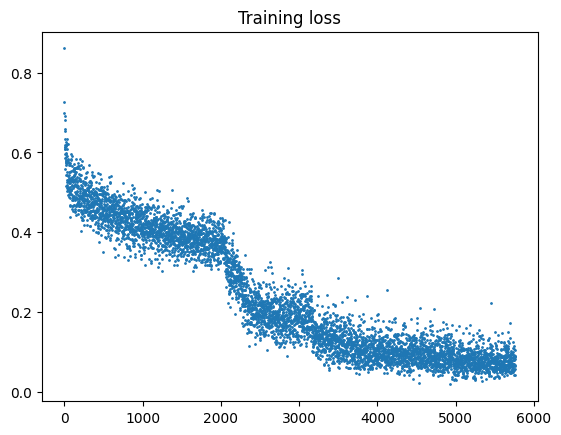

In [150]:
# Move the validation data to GPU
val_features = val_features.to(device)
val_labels = val_labels.to(device)

max_epochs = 120
print('Start training')
train_losses = []
val_losses = []

for epoch in tqdm(range(max_epochs)):
    running_loss = 0.0
    for i, data in enumerate(train_loader):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        our_net.train()
        outputs = our_net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if i % 20 == 19:    # print every 20 mini-batches
            # print(f'[{epoch + 1}, {i + 1:5d}] training loss: {running_loss / 20:.3f}')
            train_losses.append(running_loss / 20)
            running_loss = 0.0
        
print('Finished Training')

# Create a figure and subplots
plt.scatter(range(len(train_losses)), train_losses, s=1)
plt.title('Training loss')

### Testing the model

In [151]:
# load test data
test_loader = torch.utils.data.DataLoader(
    test_features,
    num_workers=0,
    worker_init_fn=seed_worker,
    batch_size=best_params["batch_size"],
    shuffle=False,
)

our_net.eval()
all_preds = []

with torch.no_grad():
    for x in test_loader:
        x = x.to(device)
        output = our_net(x)
        probs = torch.sigmoid(output)
        all_preds.append(probs.cpu())

# Concatenate predictions into a single tensor
all_preds = torch.cat(all_preds, dim=0)
pred_labels = all_preds.numpy()[:,1]

In [152]:
with open(f'{xf}.test.predicted_labels', 'w') as f:
    for item in pred_labels:
        f.write(f"{item}\n")


## 4. MGA

In [157]:
xf = 'MGA'
train_features = util.make_ohe_features_tensor(data_folder + evaluation_files_dict[xf]['train-fasta'])
train_labels = util.make_ohe_labels_tensor(data_folder + evaluation_files_dict[xf]['train-label'])
# Convert them into torch dataset
train_dataset = TutorialDataSet(train_features, train_labels)

val_features = util.make_ohe_features_tensor(data_folder + evaluation_files_dict[xf]['val-fasta'])
val_labels = util.make_ohe_labels_tensor(data_folder + evaluation_files_dict[xf]['val-label'])
# Convert them into torch dataset
val_dataset = TutorialDataSet(val_features, val_labels)

test_features = util.make_ohe_features_tensor(data_folder + evaluation_files_dict[xf]['test-fasta'])

# Instantiate our model
our_net = TutorialNet()
# Move our model to the GPU
our_net = our_net.to(device)


### Tweak hyperparameters

In [158]:
def objective(trial):
    # Define hyperparameter search space
    batch_size = trial.suggest_categorical("batch_size", [1, 2, 4, 8])
    kernel_size = trial.suggest_categorical("kernel_size", [6, 12, 18, 24])
    num_filters = trial.suggest_categorical("num_filters", [16, 64, 128, 256, 512])
    optimizer_name = trial.suggest_categorical("optimizer", ["adam", "sgd"])
    lr = trial.suggest_categorical("lr", [1e-6, 1e-5, 1e-4, 1e-3, 1e-2])

    train_loader = torch.utils.data.DataLoader(
        train_dataset,
        num_workers=0,
        worker_init_fn=seed_worker,
        batch_size=batch_size,
        shuffle=True,
    )

    val_loader = torch.utils.data.DataLoader(
        val_dataset,
        num_workers=0,
        worker_init_fn=seed_worker,
        batch_size=batch_size,
        shuffle=True,
    )

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = TutorialNet(kernel_size=kernel_size, num_filters=num_filters).to(device)

    if optimizer_name == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    criterion = CEL

    for epoch in range(1):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()

            logits = model(x)  
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

    # Validation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            if y.ndimension() > 1:  # Check if y is one-hot encoded
                y = y.argmax(dim=1)
            logits = model(x)
            preds = logits.argmax(dim=1) 
            correct += (preds == y).sum().item()
            total += y.size(0)

    acc = correct / total
    return acc

# Run the study
study = optuna.create_study(direction="maximize")
study.optimize(objective, timeout=900)

# Best trial
print("Best trial:")
trial = study.best_trial
print(f"  Accuracy: {trial.value}")
print("  Params:")
for key, value in trial.params.items():
    print(f"    {key}: {value}")


[I 2025-04-12 07:02:02,037] A new study created in memory with name: no-name-66b14995-6743-4ed9-95d0-5260abab21e5
[I 2025-04-12 07:02:05,753] Trial 0 finished with value: 0.5890322580645161 and parameters: {'batch_size': 4, 'kernel_size': 18, 'num_filters': 16, 'optimizer': 'adam', 'lr': 0.0001}. Best is trial 0 with value: 0.5890322580645161.
[I 2025-04-12 07:02:21,468] Trial 1 finished with value: 0.5129032258064516 and parameters: {'batch_size': 1, 'kernel_size': 18, 'num_filters': 512, 'optimizer': 'adam', 'lr': 1e-05}. Best is trial 0 with value: 0.5890322580645161.
[I 2025-04-12 07:02:29,390] Trial 2 finished with value: 0.6012903225806452 and parameters: {'batch_size': 2, 'kernel_size': 24, 'num_filters': 512, 'optimizer': 'adam', 'lr': 1e-05}. Best is trial 2 with value: 0.6012903225806452.
[I 2025-04-12 07:02:44,699] Trial 3 finished with value: 0.5361290322580645 and parameters: {'batch_size': 1, 'kernel_size': 24, 'num_filters': 512, 'optimizer': 'adam', 'lr': 1e-05}. Best i

Best trial:
  Accuracy: 0.6503225806451612
  Params:
    batch_size: 4
    kernel_size: 18
    num_filters: 256
    optimizer: adam
    lr: 0.0001


### Running the training with the tuned hyperparameters

In [159]:
print(best_params)

{'batch_size': 8, 'kernel_size': 6, 'num_filters': 128, 'optimizer': 'adam', 'lr': 0.001}


In [160]:
best_params = study.best_trial.params

our_net = TutorialNet(
    kernel_size=best_params["kernel_size"],
    num_filters=best_params["num_filters"]
).to(device)

if best_params["optimizer"] == "adam":
    optimizer = torch.optim.Adam(our_net.parameters(), lr=best_params["lr"])
else:
    optimizer = torch.optim.SGD(our_net.parameters(), lr=best_params["lr"], momentum=0.9)

full_train_dataset = torch.utils.data.ConcatDataset([train_dataset, val_dataset])

train_loader = torch.utils.data.DataLoader(
    full_train_dataset,
    num_workers=0,
    worker_init_fn=seed_worker,
    batch_size=best_params['batch_size'],
    shuffle=True,
)

criterion = CEL

Start training


100%|██████████| 120/120 [07:53<00:00,  3.94s/it]

Finished Training
{'batch_size': 4, 'kernel_size': 18, 'num_filters': 256, 'optimizer': 'adam', 'lr': 0.0001}


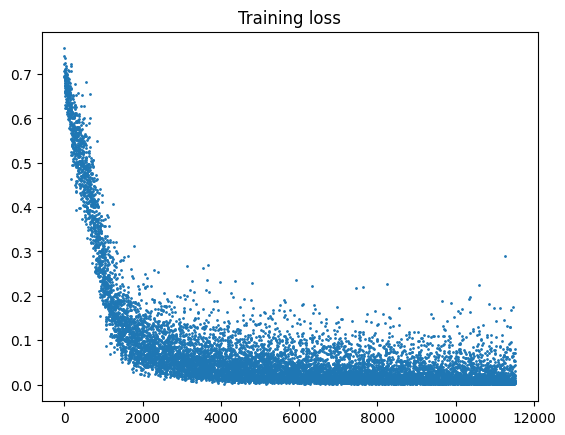

In [161]:
# Move the validation data to GPU
val_features = val_features.to(device)
val_labels = val_labels.to(device)

max_epochs = 120
print('Start training')
train_losses = []
val_losses = []

for epoch in tqdm(range(max_epochs)):
    running_loss = 0.0
    for i, data in enumerate(train_loader):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        our_net.train()
        outputs = our_net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if i % 20 == 19:    # print every 20 mini-batches
            # print(f'[{epoch + 1}, {i + 1:5d}] training loss: {running_loss / 20:.3f}')
            train_losses.append(running_loss / 20)
            running_loss = 0.0
        
print('Finished Training')

# Create a figure and subplots
plt.scatter(range(len(train_losses)), train_losses, s=1)
plt.title('Training loss')
print(best_params)

### Testing the model

In [162]:
# load test data
test_loader = torch.utils.data.DataLoader(
    test_features,
    num_workers=0,
    worker_init_fn=seed_worker,
    batch_size=best_params["batch_size"],
    shuffle=False,
)

our_net.eval()
all_preds = []


with torch.no_grad():
    for x in test_loader:
        x = x.to(device)
        output = our_net(x)
        probs = torch.sigmoid(output)
        all_preds.append(probs.cpu())

# Concatenate predictions into a single tensor
all_preds = torch.cat(all_preds, dim=0)
pred_labels = all_preds.numpy()[:,1]

In [163]:
with open(f'{xf}.test.predicted_labels', 'w') as f:
    for item in pred_labels:
        f.write(f"{item}\n")
